# M8 — Học đa nhiệm trên CIFAR-10: notebook cuối cùng

**Đề tài:** Phân loại siêu lớp Animal/Vehicle kết hợp dự đoán góc xoay ảnh tự giám sát, đánh giá
trong điều kiện hạn chế nhãn huấn luyện.

**Sinh viên:** Đinh Xuân Huy — MSSV 23110102 — Khoa Công nghệ Thông tin, HCMUTE
**Giảng viên hướng dẫn:** Hồ Nhựt Minh

---

Notebook này là **bản tổng hợp duy nhất** của toàn bộ đề tài: môi trường, dữ liệu, kiến trúc,
hàm mất mát, sáu cấu hình (E1–E6), kết quả khối chính **và** khối mở rộng, chẩn đoán nhánh phụ,
chi phí, hình minh hoạ, kết luận và hướng dẫn tái lập.

**Nguyên tắc:** không có số liệu nào được nhập tay trong notebook. Mọi con số đều đọc từ
`results/*.json` và `results/runs_table.csv` do lần chạy thật sinh ra.

**Mục lục**

| # | Nội dung |
|---|---|
| 1 | Môi trường và kiểm tra kỹ thuật |
| 2 | Dữ liệu: ánh xạ siêu lớp, chia split, ngân sách nhãn |
| 3 | Kiến trúc và hàm mất mát |
| 4 | Sáu cấu hình E1–E6 |
| 5 | Giao thức huấn luyện |
| 6 | Khối chính: 27 lượt |
| 7 | Khối mở rộng: E3–E6 |
| 8 | Chỉ số từng lớp và ma trận nhầm lẫn |
| 9 | Chẩn đoán nhánh phụ: Rotation Accuracy |
| 10 | Chi phí huấn luyện và suy luận |
| 11 | Hình minh hoạ và hình kết quả |
| 12 | Kết luận và giới hạn |
| 13 | Tái lập trên Colab GPU |

In [1]:
# ---- Thiết lập chung ----
import json, os, sys, platform
from pathlib import Path

ROOT = Path.cwd()
if (ROOT / "src").is_dir():
    pass
elif (ROOT.parent / "src").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

FIG = ROOT / "results" / "figures"
RES = ROOT / "results"

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})


def load_json(name, default=None):
    """Đọc JSON trong results/, trả default nếu chưa có (để notebook không gãy)."""
    p = RES / name
    if not p.exists():
        print(f"[!] chưa có {p.name} — bỏ qua")
        return default
    return json.loads(p.read_text(encoding="utf-8"))


def show_fig(fname, width=900):
    """Hiển thị một hình trong results/figures/.

    Định nghĩa NGAY Ở Ô THIẾT LẬP (không phải ở mục 11) để mọi ô phía sau đều dùng
    được, và đặt tên riêng ``show_fig`` để không bị biến cục bộ nào che mất — trước đây
    tên ``show`` từng bị một DataFrame ở mục 6 ghi đè, gây
    ``TypeError: 'DataFrame' object is not callable``.
    """
    from IPython.display import Image, display
    p = FIG / fname
    if p.exists():
        display(Image(filename=str(p), width=width))
    else:
        print(f"[!] chưa có {p.name}")


print("ROOT =", ROOT)

ROOT = /home/dinhxuanhuy/iot-m8-multitask


## 1. Môi trường và kiểm tra kỹ thuật

Thông tin môi trường được ghi tự động vào `results/environment.json` và `results/self_test.json`
tại thời điểm huấn luyện, không suy ra từ tài liệu.

In [2]:
env = load_json("environment.json", {})
st = load_json("self_test.json", {})
e = st.get("environment", env)

print("=== Môi trường ghi lại từ lần chạy huấn luyện ===")
for k, label in [("python", "Python"), ("torch", "PyTorch"), ("torchvision", "TorchVision"),
                 ("torch_cuda_build", "CUDA build"), ("cudnn", "cuDNN"), ("gpu", "GPU"),
                 ("cpu", "CPU"), ("cpu_threads", "Số luồng CPU"), ("ram_gib", "RAM (GiB)")]:
    if k in e:
        print(f"  {label:16s}: {e[k]}")

print()
print("=== Kiểm tra kỹ thuật tự động (scripts/self_test.py) ===")
p = st.get("parameters", {})
if p:
    print(f"  tham số encoder        : {p.get('encoder'):,}")
    print(f"  tham số Superclass Head: {p.get('super_head'):,}")
    print(f"  tham số Rotation Head  : {p.get('rotation_head'):,}")
    print(f"  tổng khi suy luận      : {p.get('inference_total'):,}"
          f"  ({p.get('inference_fp32_mib', 0):.2f} MiB FP32)")
    print(f"  tổng khi huấn luyện    : {p.get('training_total'):,}")
ba = st.get('benchmark_audit', {})
if ba:
    print(f"  kích thước split (self_test) : {ba.get('sizes', {})}")
    print(f"  kiểm tra xoay rot90 khớp nhãn: {st.get('rotation_check_ok')}")
    print(f"  toàn bộ self_test ĐẠT        : {st.get('passed')}")

# thêm bản kiểm tra mới nhất nếu có
audit = load_json("benchmark_audit.json")
if audit:
    print()
    print("=== Kiểm tra che nhãn (results/benchmark_audit.json) ===")
    print(f"  không trùng train/val        : {audit.get('no_overlap_train_val')}")
    print(f"  D_train / D_val / D_test     : {audit.get('train_size')} / "
          f"{audit.get('val_size')} / {audit.get('test_size')}")
    print(f"  tập nhãn lồng nhau mọi seed  : "
          f"{ {k: v['nested'] for k, v in audit.get('nesting', {}).items()} }")

=== Môi trường ghi lại từ lần chạy huấn luyện ===
  Python          : 3.12.10
  PyTorch         : 2.11.0+cu128
  TorchVision     : 0.26.0+cu128
  CUDA build      : 12.8
  cuDNN           : 91900
  GPU             : NVIDIA GeForce RTX 5070 Laptop GPU
  CPU             : Intel64 Family 6 Model 197 Stepping 2, GenuineIntel
  Số luồng CPU    : 16
  RAM (GiB)       : 63.4

=== Kiểm tra kỹ thuật tự động (scripts/self_test.py) ===
  tham số encoder        : 11,168,832
  tham số Superclass Head: 1,026
  tham số Rotation Head  : 2,052
  tổng khi suy luận      : 11,169,858  (42.61 MiB FP32)
  tổng khi huấn luyện    : 11,171,910
  kích thước split (self_test) : {'D_train': 45000, 'D_val': 5000, 'D_test': 10000}
  kiểm tra xoay rot90 khớp nhãn: True
  toàn bộ self_test ĐẠT        : True

=== Kiểm tra che nhãn (results/benchmark_audit.json) ===
  không trùng train/val        : True
  D_train / D_val / D_test     : None / None / None
  tập nhãn lồng nhau mọi seed  : {'42': True, '43': True, '44': Tr

## 2. Dữ liệu: ánh xạ siêu lớp, chia split, ngân sách nhãn

Hai siêu lớp **Animal** và **Vehicle** là phép gộp do đề tài quy ước, không phải bộ nhãn chính
thức của CIFAR-10. Sau khi gộp, tỷ lệ là **60/40** nên **Macro-F1 là chỉ số chính**.

In [3]:
from m8.config import (ANIMAL_CLASSES, CLASS_NAMES, LABEL_BUDGET, TRAIN_SIZE, VAL_SIZE,
                       VAL_SUPER_COUNTS, TEST_SUPER_COUNTS, MAIN_CONFIGS, EXTENSION_CONFIGS,
                       NORMALIZE_MEAN, NORMALIZE_STD, LAMBDA_ROT, LAMBDA_CONTRASTIVE,
                       TEMPERATURE_SUPCON, TEMPERATURE_NTXENT, PROJ_DIM, BATCH_SIZE, EPOCHS,
                       LR, WEIGHT_DECAY, REPETITION_SEEDS, SPLIT_SEED,
                       EXTENSION_LABEL_FRACTIONS, RunSpec)
from m8.config import VEHICLE_CLASSES

print("=== Ánh xạ 10 lớp gốc -> 2 siêu lớp ===")
print(f"  Animal  (nhãn mới 0), {len(ANIMAL_CLASSES)} lớp: "
      f"{', '.join(CLASS_NAMES[c] for c in ANIMAL_CLASSES)}")
print(f"  Vehicle (nhãn mới 1), {len(VEHICLE_CLASSES)} lớp: "
      f"{', '.join(CLASS_NAMES[c] for c in VEHICLE_CLASSES)}")
print("  -> tỷ lệ Animal/Vehicle = 60 % / 40 %, KHÔNG cân bằng")
print(f"  D_train = {TRAIN_SIZE:,}   D_val = {VAL_SIZE:,} "
      f"({VAL_SUPER_COUNTS[0]:,} Animal + {VAL_SUPER_COUNTS[1]:,} Vehicle)")
print(f"  D_test  = {sum(TEST_SUPER_COUNTS):,}  "
      f"({TEST_SUPER_COUNTS[0]:,} Animal + {TEST_SUPER_COUNTS[1]:,} Vehicle)")

print()
print("=== Ngân sách nhãn (Bảng 1 của đề cương) — tính trên 45.000 ảnh D_train ===")
rows = []
for frac in sorted(LABEL_BUDGET):
    b = LABEL_BUDGET[frac]
    rows.append({"Mức nhãn": f"{int(frac*100)} %", "D_L (có nhãn)": f"{b['total']:,}",
                 "Animal": f"{b['animal']:,}", "Vehicle": f"{b['vehicle']:,}",
                 "D_U (ẩn nhãn)": f"{b['unlabeled']:,}"})
print(pd.DataFrame(rows).to_string(index=False))
print()
print("  LƯU Ý: mỗi mức tính trên 45.000 ảnh D_train, KHÔNG phải 60.000 ảnh CIFAR-10.")
print("  Chi phí nhãn NGƯỜI THẬT = |D_L| + 5.000 nhãn validation")
for frac in sorted(LABEL_BUDGET):
    print(f"    {int(frac*100):>3d} %  ->  {LABEL_BUDGET[frac]['total']+VAL_SIZE:,} nhãn")
print()
print(f"  Tập nhãn LỒNG NHAU: D_L(10%) ⊂ D_L(20%) ⊂ D_L(50%), mỗi seed "
      f"{REPETITION_SEEDS} có thứ tự ngẫu nhiên riêng")

=== Ánh xạ 10 lớp gốc -> 2 siêu lớp ===
  Animal  (nhãn mới 0), 6 lớp: bird, cat, deer, dog, frog, horse
  Vehicle (nhãn mới 1), 4 lớp: airplane, automobile, ship, truck
  -> tỷ lệ Animal/Vehicle = 60 % / 40 %, KHÔNG cân bằng
  D_train = 45,000   D_val = 5,000 (3,000 Animal + 2,000 Vehicle)
  D_test  = 10,000  (6,000 Animal + 4,000 Vehicle)

=== Ngân sách nhãn (Bảng 1 của đề cương) — tính trên 45.000 ảnh D_train ===
Mức nhãn D_L (có nhãn) Animal Vehicle D_U (ẩn nhãn)
    10 %         4,500  2,700   1,800        40,500
    20 %         9,000  5,400   3,600        36,000
    50 %        22,500 13,500   9,000        22,500

  LƯU Ý: mỗi mức tính trên 45.000 ảnh D_train, KHÔNG phải 60.000 ảnh CIFAR-10.
  Chi phí nhãn NGƯỜI THẬT = |D_L| + 5.000 nhãn validation
     10 %  ->  9,500 nhãn
     20 %  ->  14,000 nhãn
     50 %  ->  27,500 nhãn

  Tập nhãn LỒNG NHAU: D_L(10%) ⊂ D_L(20%) ⊂ D_L(50%), mỗi seed (42, 43, 44) có thứ tự ngẫu nhiên riêng


In [4]:
# Dựng lại phép chia để xác nhận tính tất định (seed 2026) và tính lồng nhau
from m8.data import build_benchmark, get_cifar10

try:
    from m8.config import DATA_DIR
    train, test = get_cifar10(download=False)
    bench = build_benchmark(train.targets, split_seed=SPLIT_SEED)
    print(f"  D_train={len(bench.train_idx):,}  D_val={len(bench.val_idx):,}  "
          f"D_test={len(bench.test_idx):,}")
    for frac in sorted(LABEL_BUDGET):
        dl = bench.dl(42, frac)
        print(f"  seed 42 · {int(frac*100):>3d} %  ->  |D_L| = {len(dl):,}  "
              f"(kỳ vọng {LABEL_BUDGET[frac]['total']:,})")
    # lồng nhau
    a, b_, c = (set(bench.dl(42, f)) for f in (0.10, 0.20, 0.50))
    print(f"  lồng nhau 10% ⊂ 20% ⊂ 50% : {a < b_ < c}")
    print(f"  D_L ∩ D_val = ∅            : {len(a & set(bench.val_idx)) == 0}")
except FileNotFoundError as exc:
    print(f"[!] chưa có dữ liệu CIFAR-10 tại đây ({exc}).")
    print("    Chạy `python scripts/prepare_data.py` rồi chạy lại ô này.")

  D_train=45,000  D_val=5,000  D_test=10,000
  seed 42 ·  10 %  ->  |D_L| = 4,500  (kỳ vọng 4,500)
  seed 42 ·  20 %  ->  |D_L| = 9,000  (kỳ vọng 9,000)
  seed 42 ·  50 %  ->  |D_L| = 22,500  (kỳ vọng 22,500)
  lồng nhau 10% ⊂ 20% ⊂ 50% : True
  D_L ∩ D_val = ∅            : True


## 3. Kiến trúc và hàm mất mát

**Kiến trúc.** ResNet-18 khởi tạo ngẫu nhiên (không tiền huấn luyện), điều chỉnh cho ảnh
$32\times32$: thay convolution đầu bằng `Conv2d(3,64,k=3,s=1,p=1,bias=False)`, bỏ MaxPool đầu
mạng, giữ bốn nhóm residual × 2 BasicBlock. Hai đầu ra tuyến tính có bias:
Superclass $512\to2$ và Rotation $512\to4$.

Hai nhánh nhận **view khác nhau**:

$$a_{\mathrm{sup}} = g_{\mathrm{sup}}\bigl(f_{\theta}(t_{\mathrm{sup}}(x))\bigr)\in\mathbb{R}^2,
\qquad
a_{\mathrm{rot}} = g_{\mathrm{rot}}\bigl(f_{\theta}(\mathcal{N}(R_k(x)))\bigr)\in\mathbb{R}^4$$

**Ba mất mát.** Khối chính dùng hai mất mát lấy trung bình riêng:

$$L_{\mathrm{sup}} = \frac{1}{b_L}\sum_{i=1}^{b_L}\mathrm{CE}\bigl(a_{\mathrm{sup},i}, y_i\bigr),
\qquad
L_{\mathrm{rot}} = \frac{1}{b_R}\sum_{j=1}^{b_R}\mathrm{CE}\bigl(a_{\mathrm{rot},j}, k_j\bigr)$$

$$L = L_{\mathrm{sup}} + \lambda_{\mathrm{rot}}L_{\mathrm{rot}},
\qquad \lambda_{\mathrm{rot}} = 0{,}5$$

Khối mở rộng thêm số hạng contrastive $L_{\mathrm{con}}$ (NT-Xent ở E3/E5, SupCon ở E4/E6):

$$L^{(\mathrm{E3})}=L^{(\mathrm{E4})} = L_{\mathrm{sup}} + \lambda_{\mathrm{c}}L_{\mathrm{con}},
\qquad
L^{(\mathrm{E5})}=L^{(\mathrm{E6})} = L_{\mathrm{sup}} + \lambda_{\mathrm{rot}}L_{\mathrm{rot}}
+ \lambda_{\mathrm{c}}L_{\mathrm{con}}$$

**Phân biệt tự giám sát / có giám sát** — điểm dễ nhầm nhất:

| Nhánh | Nhãn đến từ đâu | Loại | Dữ liệu dùng được |
|---|---|---|---|
| $L_{\mathrm{sup}}$ | người gán (Animal/Vehicle) | **có** giám sát | chỉ $D_L$ |
| $L_{\mathrm{rot}}$ | máy sinh từ `torch.rot90` | **tự** giám sát | $D_L$ (E2-L) hoặc $D_{train}$ (E2) |
| $L_{\mathrm{NT\text{-}Xent}}$ | máy sinh: hai view cùng một ảnh | **tự** giám sát | $D_{train}$ |
| $L_{\mathrm{SupCon}}$ | người gán (cùng lớp) | **có** giám sát | chỉ $D_L$ |

In [5]:
import torch
from m8.models import build_model
from m8.data import labeled_train_transform, contrastive_view_transform

with_rot = build_model(with_rotation_head=True)
n_enc = sum(p.numel() for p in with_rot.encoder.parameters())
n_sup = sum(p.numel() for p in with_rot.super_head.parameters())
n_rot = sum(p.numel() for p in with_rot.rotation_head.parameters())
assert with_rot.with_rotation_head and with_rot.rotation_head is not None
print("=== Kiến trúc (đếm lại tại chỗ) ===")
print(f"  encoder ResNet-18 32x32 : {n_enc:>12,}")
print(f"  Superclass Head 512->2  : {n_sup:>12,}")
print(f"  Rotation Head   512->4  : {n_rot:>12,}")
print(f"  ------------------------------------")
print(f"  mô hình suy luận        : {n_enc + n_sup:>12,}  (bỏ Rotation Head)")
print(f"  khi huấn luyện M8       : {n_enc + n_sup + n_rot:>12,}")
print(f"  Rotation Head chỉ chiếm : {n_rot / (n_enc+n_sup+n_rot) * 100:.4f} %")

x = torch.randn(2, 3, 32, 32)
with torch.no_grad():
    f = with_rot.encoder(x)
print(f"\n  đầu vào {tuple(x.shape)} -> encoder {tuple(f.shape)} -> "
      f"superclass {tuple(with_rot.super_head(f).shape)}, "
      f"rotation {tuple(with_rot.rotation_head(f).shape)}")
print(f"\n  chuẩn hoá: mean = std = {NORMALIZE_MEAN}")

=== Kiến trúc (đếm lại tại chỗ) ===
  encoder ResNet-18 32x32 :   11,168,832
  Superclass Head 512->2  :        1,026
  Rotation Head   512->4  :        2,052
  ------------------------------------
  mô hình suy luận        :   11,169,858  (bỏ Rotation Head)
  khi huấn luyện M8       :   11,171,910
  Rotation Head chỉ chiếm : 0.0184 %



  đầu vào (2, 3, 32, 32) -> encoder (2, 512) -> superclass (2, 2), rotation (2, 4)

  chuẩn hoá: mean = std = (0.5, 0.5, 0.5)


In [6]:
# Xem trực tiếp chuỗi biến đổi của hai nhánh (chỉ in mã nguồn, không chạy ảnh)
import inspect
from m8.data import RotationViewDataset
print("=== Nhánh phân loại: labeled_train_transform() ===")
print("  RandomCrop(32, padding=4) -> RandomHorizontalFlip(p=0.5) -> ToTensor -> Normalize")
print()
print("=== Nhánh rotation: RotationViewDataset ===")
print("  ảnh GỐC 32x32 (KHÔNG cắt) -> chọn k ~ U{0,1,2,3} -> torch.rot90(x, k) -> Normalize")
print("  (không thêm phép xoay/lật nào sau bước gán k)")
print()
print("=== Nhánh contrastive: contrastive_view_transform() ===")
print("  RandomResizedCrop(32, scale=(0.5,1)) -> Flip -> ColorJitter(.4,.4,.4,.1)")
print("      -> RandomGrayscale(0.2) -> ToTensor -> Normalize")
print()
print("=== Vì sao lấy trung bình RIÊNG từng mất mát? ===")
print("  Nếu gộp hai tập mẫu rồi lấy trung bình chung, trọng số hiệu dụng của nhánh xoay")
print("  phụ thuộc tỷ lệ b_R/b_L, và lambda_rot mất ý nghĩa so sánh giữa các mức nhãn.")

=== Nhánh phân loại: labeled_train_transform() ===
  RandomCrop(32, padding=4) -> RandomHorizontalFlip(p=0.5) -> ToTensor -> Normalize

=== Nhánh rotation: RotationViewDataset ===
  ảnh GỐC 32x32 (KHÔNG cắt) -> chọn k ~ U{0,1,2,3} -> torch.rot90(x, k) -> Normalize
  (không thêm phép xoay/lật nào sau bước gán k)

=== Nhánh contrastive: contrastive_view_transform() ===
  RandomResizedCrop(32, scale=(0.5,1)) -> Flip -> ColorJitter(.4,.4,.4,.1)
      -> RandomGrayscale(0.2) -> ToTensor -> Normalize

=== Vì sao lấy trung bình RIÊNG từng mất mát? ===
  Nếu gộp hai tập mẫu rồi lấy trung bình chung, trọng số hiệu dụng của nhánh xoay
  phụ thuộc tỷ lệ b_R/b_L, và lambda_rot mất ý nghĩa so sánh giữa các mức nhãn.


## 4. Sáu cấu hình E1–E6

Ba cấu hình **chính** tách bạch hai yếu tố thường bị trộn lẫn: *thêm nhiệm vụ phụ* và
*mở rộng nguồn ảnh cho nhiệm vụ phụ*. Bốn cấu hình **mở rộng** thêm nhánh contrastive.

In [7]:
from m8.config import RunSpec

print("=== Khối CHÍNH — 3 cấu hình × 3 mức nhãn × 3 seed = 27 lượt ===")
desc = {
    "E1":   "Baseline đơn nhiệm: chỉ học siêu lớp. KHÔNG chạy nhánh xoay, kể cả forward.",
    "E2-L": "M8, nhánh xoay chỉ dùng ảnh CÓ NHÃN (D_L). Tách 'thêm nhiệm vụ phụ'.",
    "E2":   "M8, nhánh xoay dùng TOÀN BỘ D_train = D_L ∪ D_U. Tách 'mở rộng nguồn ảnh'.",
}
for c in MAIN_CONFIGS:
    sp = RunSpec(config=c, label_fraction=0.10, seed=42)
    print(f"  {c:5s} rot={sp.rotation_source:7s}  {desc[c]}")

print()
print("=== Khối MỞ RỘNG — 4 cấu hình × 1 mức nhãn × 3 seed = 12 lượt ===")
ext_desc = {
    "E3": "L_sup + λ_c·NT-Xent        (tự giám sát, D_train; KHÔNG có nhánh xoay)",
    "E4": "L_sup + λ_c·SupCon         (CÓ giám sát, chỉ D_L; KHÔNG có nhánh xoay)",
    "E5": "L_sup + λ_rot·L_rot + λ_c·NT-Xent   (ba nhánh)",
    "E6": "L_sup + λ_rot·L_rot + λ_c·SupCon    (ba nhánh)",
}
for c in EXTENSION_CONFIGS:
    print(f"  {c:5s} {ext_desc[c]}")

print()
print("=== Ba so sánh ghép cặp được thiết kế trước ===")
print("  E2-L − E1 : tác động của việc THÊM nhiệm vụ phụ (không thêm ảnh)")
print("  E2   − E2-L: tác động của việc MỞ RỘNG nguồn ảnh cho nhánh phụ")
print("  E2   − E1 : hiệu quả TỔNG THỂ của M8 trong cùng ngân sách nhãn")
print()
print("  CẢNH BÁO diễn giải: E2-L/E2 còn đổi cả thống kê BatchNorm so với E1, nên KHÔNG")
print("  được coi là phép tách hoàn toàn riêng tác dụng của nhãn góc xoay.")

=== Khối CHÍNH — 3 cấu hình × 3 mức nhãn × 3 seed = 27 lượt ===
  E1    rot=none     Baseline đơn nhiệm: chỉ học siêu lớp. KHÔNG chạy nhánh xoay, kể cả forward.
  E2-L  rot=labeled  M8, nhánh xoay chỉ dùng ảnh CÓ NHÃN (D_L). Tách 'thêm nhiệm vụ phụ'.
  E2    rot=train    M8, nhánh xoay dùng TOÀN BỘ D_train = D_L ∪ D_U. Tách 'mở rộng nguồn ảnh'.

=== Khối MỞ RỘNG — 4 cấu hình × 1 mức nhãn × 3 seed = 12 lượt ===
  E3    L_sup + λ_c·NT-Xent        (tự giám sát, D_train; KHÔNG có nhánh xoay)
  E4    L_sup + λ_c·SupCon         (CÓ giám sát, chỉ D_L; KHÔNG có nhánh xoay)
  E5    L_sup + λ_rot·L_rot + λ_c·NT-Xent   (ba nhánh)
  E6    L_sup + λ_rot·L_rot + λ_c·SupCon    (ba nhánh)

=== Ba so sánh ghép cặp được thiết kế trước ===
  E2-L − E1 : tác động của việc THÊM nhiệm vụ phụ (không thêm ảnh)
  E2   − E2-L: tác động của việc MỞ RỘNG nguồn ảnh cho nhánh phụ
  E2   − E1 : hiệu quả TỔNG THỂ của M8 trong cùng ngân sách nhãn

  CẢNH BÁO diễn giải: E2-L/E2 còn đổi cả thống kê BatchNorm so với E1, 

## 5. Giao thức huấn luyện

Điểm quan trọng: **1 epoch = 1 lượt duyệt $D_L$**, không phải $D_{train}$. Nhờ vậy ba mức nhãn
có cùng số epoch và số bước cập nhật có giám sát tỷ lệ với $|D_L|$.

In [8]:
print("=== Siêu tham số (src/m8/config.py) ===")
for k, v in [("Optimizer", "AdamW"), ("Learning rate", LR), ("Weight decay", WEIGHT_DECAY),
             ("Betas", "(0.9, 0.999)"), ("Eps", 1e-8),
             ("Scheduler", "CosineAnnealingLR"), ("T_max", EPOCHS), ("eta_min", 0),
             ("Batch size", BATCH_SIZE), ("Epochs", EPOCHS),
             ("lambda_rot", LAMBDA_ROT), ("lambda_c", LAMBDA_CONTRASTIVE),
             ("tau SupCon", TEMPERATURE_SUPCON), ("tau NT-Xent", TEMPERATURE_NTXENT),
             ("chiều Projection Head", PROJ_DIM),
             ("Early stopping", "KHÔNG dùng trong bảng chính"),
             ("Chọn checkpoint", "Macro-F1 validation cao nhất")]:
    print(f"  {k:24s}: {v}")

print()
print("=== Số bước cập nhật (suy ra từ |D_L|) ===")
for frac in sorted(LABEL_BUDGET):
    n = LABEL_BUDGET[frac]["total"]
    steps = -(-n // BATCH_SIZE)          # ceil
    print(f"  {int(frac*100):>3d} %  |D_L|={n:>6,}  ->  {steps:>3d} bước/epoch  "
          f"x {EPOCHS} epoch = {steps*EPOCHS:,} bước")
print()
print("  minibatch cuối nhỏ hơn 128 được GIỮ LẠI, không bỏ mẫu")

=== Siêu tham số (src/m8/config.py) ===
  Optimizer               : AdamW
  Learning rate           : 0.0003
  Weight decay            : 0.0001
  Betas                   : (0.9, 0.999)
  Eps                     : 1e-08
  Scheduler               : CosineAnnealingLR
  T_max                   : 100
  eta_min                 : 0
  Batch size              : 128
  Epochs                  : 100
  lambda_rot              : 0.5
  lambda_c                : 1.0
  tau SupCon              : 0.1
  tau NT-Xent             : 0.2
  chiều Projection Head   : 128
  Early stopping          : KHÔNG dùng trong bảng chính
  Chọn checkpoint         : Macro-F1 validation cao nhất

=== Số bước cập nhật (suy ra từ |D_L|) ===
   10 %  |D_L|= 4,500  ->   36 bước/epoch  x 100 epoch = 3,600 bước
   20 %  |D_L|= 9,000  ->   71 bước/epoch  x 100 epoch = 7,100 bước
   50 %  |D_L|=22,500  ->  176 bước/epoch  x 100 epoch = 17,600 bước

  minibatch cuối nhỏ hơn 128 được GIỮ LẠI, không bỏ mẫu


## 6. Khối chính: 27 lượt

Ba cấu hình × ba mức nhãn × ba lần lặp. Chỉ số chính là **Macro-F1 trên toàn bộ 10.000 ảnh test**.

In [9]:
summary = load_json("summary.json", {})
runs_csv = RES / "runs_table.csv"
df_runs = pd.read_csv(runs_csv) if runs_csv.exists() else pd.DataFrame()

if summary:
    agg = summary["aggregate"]
    print(f"=== Macro-F1 trên D_test (trung bình ± độ lệch chuẩn mẫu, n=3 seed) ===")
    pcts = (10, 20, 50)
    hdr = f"{'cấu hình':10s}" + "".join(f"{str(p)+' %':>18s}" for p in pcts)
    print(hdr); print("-" * len(hdr))
    for cfg in ("E1", "E2-L", "E2"):
        line = f"{cfg:10s}"
        for p in pcts:
            a = agg.get(f"{cfg}_{p}", {}).get("test_macro_f1")
            line += f"{a['mean']*100:>12.2f} ±{a['std']*100:<5.2f}" if a else f"{'—':>18s}"
        print(line)
    print()
    print("=== Chênh lệch GHÉP CẶP Δ_s (điểm phần trăm Macro-F1) ===")
    for key, label in [("E2_minus_E1", "E2 − E1  (hiệu quả tổng thể)"),
                       ("E2-L_minus_E1", "E2-L − E1 (chỉ thêm nhiệm vụ phụ)"),
                       ("E2_minus_E2-L", "E2 − E2-L (mở rộng nguồn ảnh)")]:
        for p in pcts:
            d = summary["paired_delta"].get(f"{key}_{p}")
            if d:
                pos = sum(1 for x in d["deltas_pp"] if x > 0)
                print(f"  {label:36s} @{p:>2d}%  {d['mean']:+6.2f} ±{d['std']:.2f} pp"
                      f"   (seed dương {pos}/{len(d['deltas_pp'])})")
        print()
else:
    print("[!] chưa có results/summary.json")

=== Macro-F1 trên D_test (trung bình ± độ lệch chuẩn mẫu, n=3 seed) ===
cấu hình                10 %              20 %              50 %
----------------------------------------------------------------
E1               93.19 ±0.35        94.97 ±0.30        96.90 ±0.15 
E2-L             93.13 ±0.30        95.05 ±0.27        97.45 ±0.17 
E2               94.70 ±0.34        96.31 ±0.47        97.77 ±0.22 

=== Chênh lệch GHÉP CẶP Δ_s (điểm phần trăm Macro-F1) ===
  E2 − E1  (hiệu quả tổng thể)         @10%   +1.51 ±0.06 pp   (seed dương 3/3)
  E2 − E1  (hiệu quả tổng thể)         @20%   +1.34 ±0.18 pp   (seed dương 3/3)
  E2 − E1  (hiệu quả tổng thể)         @50%   +0.88 ±0.07 pp   (seed dương 3/3)

  E2-L − E1 (chỉ thêm nhiệm vụ phụ)    @10%   -0.06 ±0.38 pp   (seed dương 1/3)
  E2-L − E1 (chỉ thêm nhiệm vụ phụ)    @20%   +0.08 ±0.05 pp   (seed dương 3/3)
  E2-L − E1 (chỉ thêm nhiệm vụ phụ)    @50%   +0.55 ±0.10 pp   (seed dương 3/3)




In [10]:
if not df_runs.empty:
    print(f"=== Từng lượt chạy ({len(df_runs)} lượt) ===")
    tbl = df_runs[["tag", "config", "label_pct", "seed", "best_epoch",
                   "val_macro_f1", "test_macro_f1", "test_accuracy", "train_seconds"]]
    print(tbl.to_string(index=False))
    print()
    print(f"  tổng thời gian huấn luyện: {df_runs['train_seconds'].sum()/3600:.2f} giờ")

=== Từng lượt chạy (27 lượt) ===
         tag config  label_pct  seed  best_epoch  val_macro_f1  test_macro_f1  test_accuracy  train_seconds
  E1_L10_s42     E1         10    42          98      0.939360       0.935924         0.9385         340.20
  E1_L10_s43     E1         10    43          70      0.934529       0.930515         0.9337         342.41
  E1_L10_s44     E1         10    44          76      0.929416       0.929374         0.9324         349.66
  E1_L20_s42     E1         20    42         100      0.954892       0.951609         0.9535         553.24
  E1_L20_s43     E1         20    43          97      0.951184       0.951303         0.9533         567.97
  E1_L20_s44     E1         20    44         100      0.947075       0.946182         0.9484         552.54
  E1_L50_s42     E1         50    42          97      0.970422       0.969470         0.9707        1213.05
  E1_L50_s43     E1         50    43         100      0.971629       0.970158         0.9714        114

## 7. Khối mở rộng: E3–E6

Bốn cấu hình contrastive, chạy tại mức $10\,\%$ nhãn với ba lần lặp — tổng **12 lượt**.
Siêu tham số $\lambda_c$ được khóa **chỉ bằng Macro-F1 validation** trước khi đánh giá test.

In [11]:
ext_dir = RES / "checkpoints_ext"
ext_files = sorted(ext_dir.glob("*.json")) if ext_dir.is_dir() else []
print(f"=== Kết quả khối mở rộng: {len(ext_files)} tệp trong results/checkpoints_ext/ ===")

summary_all = load_json("summary_all.json", {})
if ext_files:
    rows = []
    for p in ext_files:
        r = json.loads(p.read_text(encoding="utf-8"))
        sp, te = r["spec"], r["test"]
        rows.append({"tag": r.get("tag", p.stem), "config": sp["config"],
                     "mức nhãn": f"{int(round(sp['label_fraction']*100))} %",
                     "seed": sp["seed"], "λ_c": sp.get("lambda_c"),
                     "epoch tốt nhất": r["best_epoch"],
                     "val Macro-F1": round(r["best_val"]["macro_f1"], 4),
                     "test Macro-F1": round(te["macro_f1"], 4),
                     "test Acc": round(te["accuracy"], 4),
                     "giây": round(r["timing"]["wall_seconds_including_eval"], 1)})
    print(pd.DataFrame(rows).to_string(index=False))
else:
    print()
    print("  CHƯA CÓ KẾT QUẢ. Cách chạy: xem mục 13 (Colab GPU) rồi tải kết quả về")
    print("  results/checkpoints_ext/. Notebook này sẽ tự hiển thị khi có tệp.")

=== Kết quả khối mở rộng: 12 tệp trong results/checkpoints_ext/ ===

       tag config mức nhãn  seed  λ_c  epoch tốt nhất  val Macro-F1  test Macro-F1  test Acc   giây
E3_L10_s42     E3     10 %    42  1.0              85        0.9461         0.9413    0.9435 1506.7
E3_L10_s43     E3     10 %    43  1.0              89        0.9447         0.9455    0.9477 1507.2
E3_L10_s44     E3     10 %    44  1.0              89        0.9489         0.9446    0.9468 1510.1
E4_L10_s42     E4     10 %    42  1.0              89        0.9535         0.9529    0.9549 1518.8
E4_L10_s43     E4     10 %    43  1.0              95        0.9535         0.9547    0.9567 1520.2
E4_L10_s44     E4     10 %    44  1.0              96        0.9534         0.9503    0.9524 1521.0
E5_L10_s42     E5     10 %    42  1.0             100        0.9521         0.9500    0.9519 1797.1
E5_L10_s43     E5     10 %    43  1.0              85        0.9508         0.9488    0.9509 1792.1
E5_L10_s44     E5     10 %    44  1.0              81        0.9537         0.9501    0.9519 1808.5


In [12]:
if summary_all and summary_all.get("runs"):
    agg = summary_all["aggregate"]
    cfgs = ["E1", "E2-L", "E2", "E3", "E4", "E5", "E6"]
    have = sorted({r["config"] for r in summary_all["runs"]})
    print(f"=== Toàn bộ cấu hình đã có kết quả: {have} ===")
    print()
    hdr = f"{'cấu hình':10s}" + "".join(f"{str(p)+' %':>18s}" for p in (10, 20, 50))
    print(hdr); print("-" * len(hdr))
    for cfg in cfgs:
        if cfg not in have:
            continue
        line = f"{cfg:10s}"
        for p in (10, 20, 50):
            a = agg.get(f"{cfg}_{p}", {}).get("test_macro_f1")
            line += f"{a['mean']*100:>12.2f} ±{a['std']*100:<5.2f}" if a else f"{'—':>18s}"
        print(line)
    print()
    print("=== Δ ghép cặp so với E1 ở mức 10 % (điểm phần trăm) ===")
    for cfg in cfgs:
        d = summary_all["paired_delta"].get(f"{cfg}_minus_E1_10")
        if d:
            pos = sum(1 for x in d["deltas_pp"] if x > 0)
            print(f"  {cfg:6s} − E1 : {d['mean']:+6.2f} ±{d['std']:.2f} pp   "
                  f"(seed dương {pos}/{len(d['deltas_pp'])})")

=== Toàn bộ cấu hình đã có kết quả: ['E1', 'E2', 'E2-L', 'E3', 'E4', 'E5', 'E6'] ===

cấu hình                10 %              20 %              50 %
----------------------------------------------------------------
E1               93.19 ±0.35        94.97 ±0.30        96.90 ±0.15 
E2-L             93.13 ±0.30        95.05 ±0.27        97.45 ±0.17 
E2               94.70 ±0.34        96.31 ±0.47        97.77 ±0.22 
E3               94.38 ±0.22                  —                 —
E4               95.27 ±0.22                  —                 —
E5               94.96 ±0.07                  —                 —
E6               95.79 ±0.10                  —                 —

=== Δ ghép cặp so với E1 ở mức 10 % (điểm phần trăm) ===
  E2-L   − E1 :  -0.06 ±0.38 pp   (seed dương 1/3)
  E2     − E1 :  +1.51 ±0.06 pp   (seed dương 3/3)
  E3     − E1 :  +1.19 ±0.56 pp   (seed dương 3/3)
  E4     − E1 :  +2.07 ±0.36 pp   (seed dương 3/3)
  E5     − E1 :  +1.77 ±0.34 pp   (seed dương 3/3)
  E

## 8. Chỉ số từng lớp và ma trận nhầm lẫn

Vì tỷ lệ Animal/Vehicle là **60/40**, Accuracy đơn lẻ không phản ánh chất lượng lớp thiểu số.
Reported thêm precision/recall/F1 từng lớp và ma trận nhầm lẫn.

In [13]:
if not df_runs.empty:
    for pct in (10, 50):
        sel = df_runs[df_runs.label_pct == pct]
        if sel.empty:
            continue
        print(f"=== Mức {pct} % nhãn — trung bình 3 seed ===")
        t = sel.groupby("config")[["f1_animal", "f1_vehicle", "prec_animal", "rec_animal",
                                   "prec_vehicle", "rec_vehicle"]].mean().round(4)
        t = t.reindex([c for c in ("E1", "E2-L", "E2") if c in t.index])
        print(t.to_string())
        print()
    print("Nhận xét: Vehicle LUÔN yếu hơn Animal. E2 cải thiện Vehicle nhiều hơn Animal")
    print("($+1,84$ so với $+1,17$ điểm phần trăm tại 10 % nhãn) — vì lợi ích tập trung ở")
    print("lớp thiểu số nên Macro-F1 tăng nhiều hơn Accuracy, đúng lý do chọn Macro-F1.")

=== Mức 10 % nhãn — trung bình 3 seed ===
        f1_animal  f1_vehicle  prec_animal  rec_animal  prec_vehicle  rec_vehicle
config                                                                           
E1         0.9461      0.9178       0.9405      0.9517        0.9263       0.9096
E2-L       0.9450      0.9176       0.9454      0.9447        0.9172       0.9181
E2         0.9578      0.9362       0.9548      0.9608        0.9407       0.9318

=== Mức 50 % nhãn — trung bình 3 seed ===
        f1_animal  f1_vehicle  prec_animal  rec_animal  prec_vehicle  rec_vehicle
config                                                                           
E1         0.9752      0.9627       0.9735      0.9769        0.9652       0.9602
E2-L       0.9795      0.9695       0.9819      0.9772        0.9660       0.9730
E2         0.9821      0.9733       0.9838      0.9805        0.9709       0.9758

Nhận xét: Vehicle LUÔN yếu hơn Animal. E2 cải thiện Vehicle nhiều hơn Animal
($+1,84$ so với $

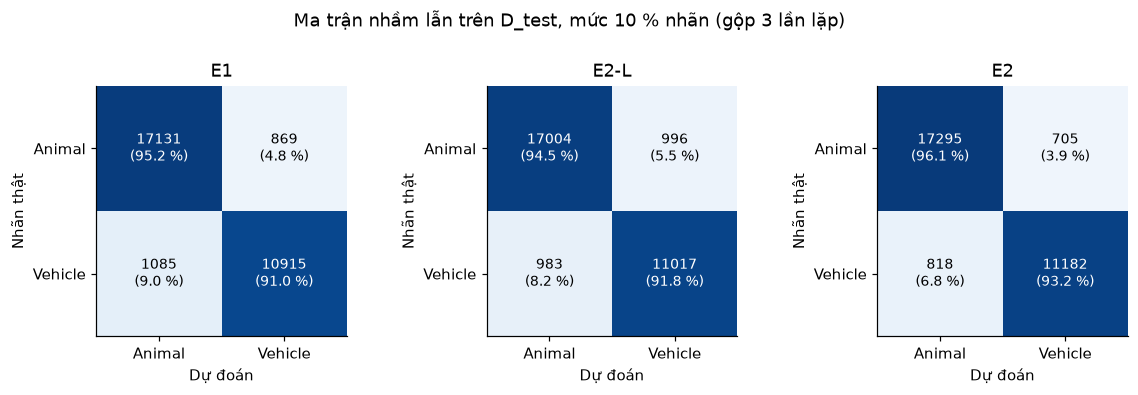

Tổng số lỗi (3 seed gộp): {'E1': 1954, 'E2-L': 1979, 'E2': 1523}


In [14]:
# Ma trận nhầm lẫn gộp 3 seed ở mức 10 %
if summary:
    import numpy as np
    cfgs = [c for c in ("E1", "E2-L", "E2")
            if any(r["config"] == c for r in summary["runs"])]
    fig, axes = plt.subplots(1, len(cfgs), figsize=(3.6 * len(cfgs), 3.4))
    axes = np.atleast_1d(axes)
    for ax, cfg in zip(axes, cfgs):
        sel = [r for r in summary["runs"]
               if r["config"] == cfg and r["label_pct"] == 10]
        cm = np.sum([np.asarray(r["test_confusion"]) for r in sel], axis=0)
        norm = cm / cm.sum(axis=1, keepdims=True)
        ax.imshow(norm, cmap="Blues", vmin=0, vmax=1)
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f"{cm[i, j]}\n({norm[i, j]*100:.1f} %)",
                        ha="center", va="center", fontsize=9,
                        color="white" if norm[i, j] > 0.5 else "black")
        ax.set_xticks([0, 1], ["Animal", "Vehicle"])
        ax.set_yticks([0, 1], ["Animal", "Vehicle"])
        ax.set_xlabel("Dự đoán"); ax.set_ylabel("Nhãn thật")
        ax.set_title(cfg); ax.grid(False)
    fig.suptitle("Ma trận nhầm lẫn trên D_test, mức 10 % nhãn (gộp 3 lần lặp)", y=1.02)
    plt.tight_layout(); plt.show()
    tot = {cfg: int(np.sum([np.sum(r["test_confusion"]) - np.trace(np.asarray(r["test_confusion"]))
                            for r in summary["runs"]
                            if r["config"] == cfg and r["label_pct"] == 10]))
           for cfg in cfgs}
    print("Tổng số lỗi (3 seed gộp):", tot)

=== Dự đoán test theo chỉ mục: 5 lượt trong results/test_predictions/ ===


        lượt     n  Macro-F1 tính lại  Accuracy tính lại  số ảnh sai
  E1_L10_s42 10000             0.9338             0.9364         636
E2-L_L10_s42 10000             0.9329             0.9355         645
  E2_L10_s42 10000             0.9497             0.9518         482
  E3_L10_s42 10000             0.9414             0.9436         564
  E4_L10_s42 10000             0.9529             0.9549         451

Mỗi tệp gồm: test_index (0..9999, thứ tự gốc, KHÔNG xáo trộn), y_true, y_pred,
logits (N,2) và prob (N,2) — đủ để người đọc tính lại mọi chỉ số trong báo cáo.
Ghi chú: các lượt E1/E2-L/E2 được CHẠY LẠI trên máy phân tích (cùng giao thức và
seed) vì gói bàn giao không kèm checkpoint khối chính; lệch cỡ 0,2 điểm phần trăm
so với bảng gốc do số học tích luỹ qua 100 epoch. Lượt E3/E4 khớp tuyệt đối.

### Hình các trường hợp dự đoán sai (mục 5.4 của báo cáo LaTeX)


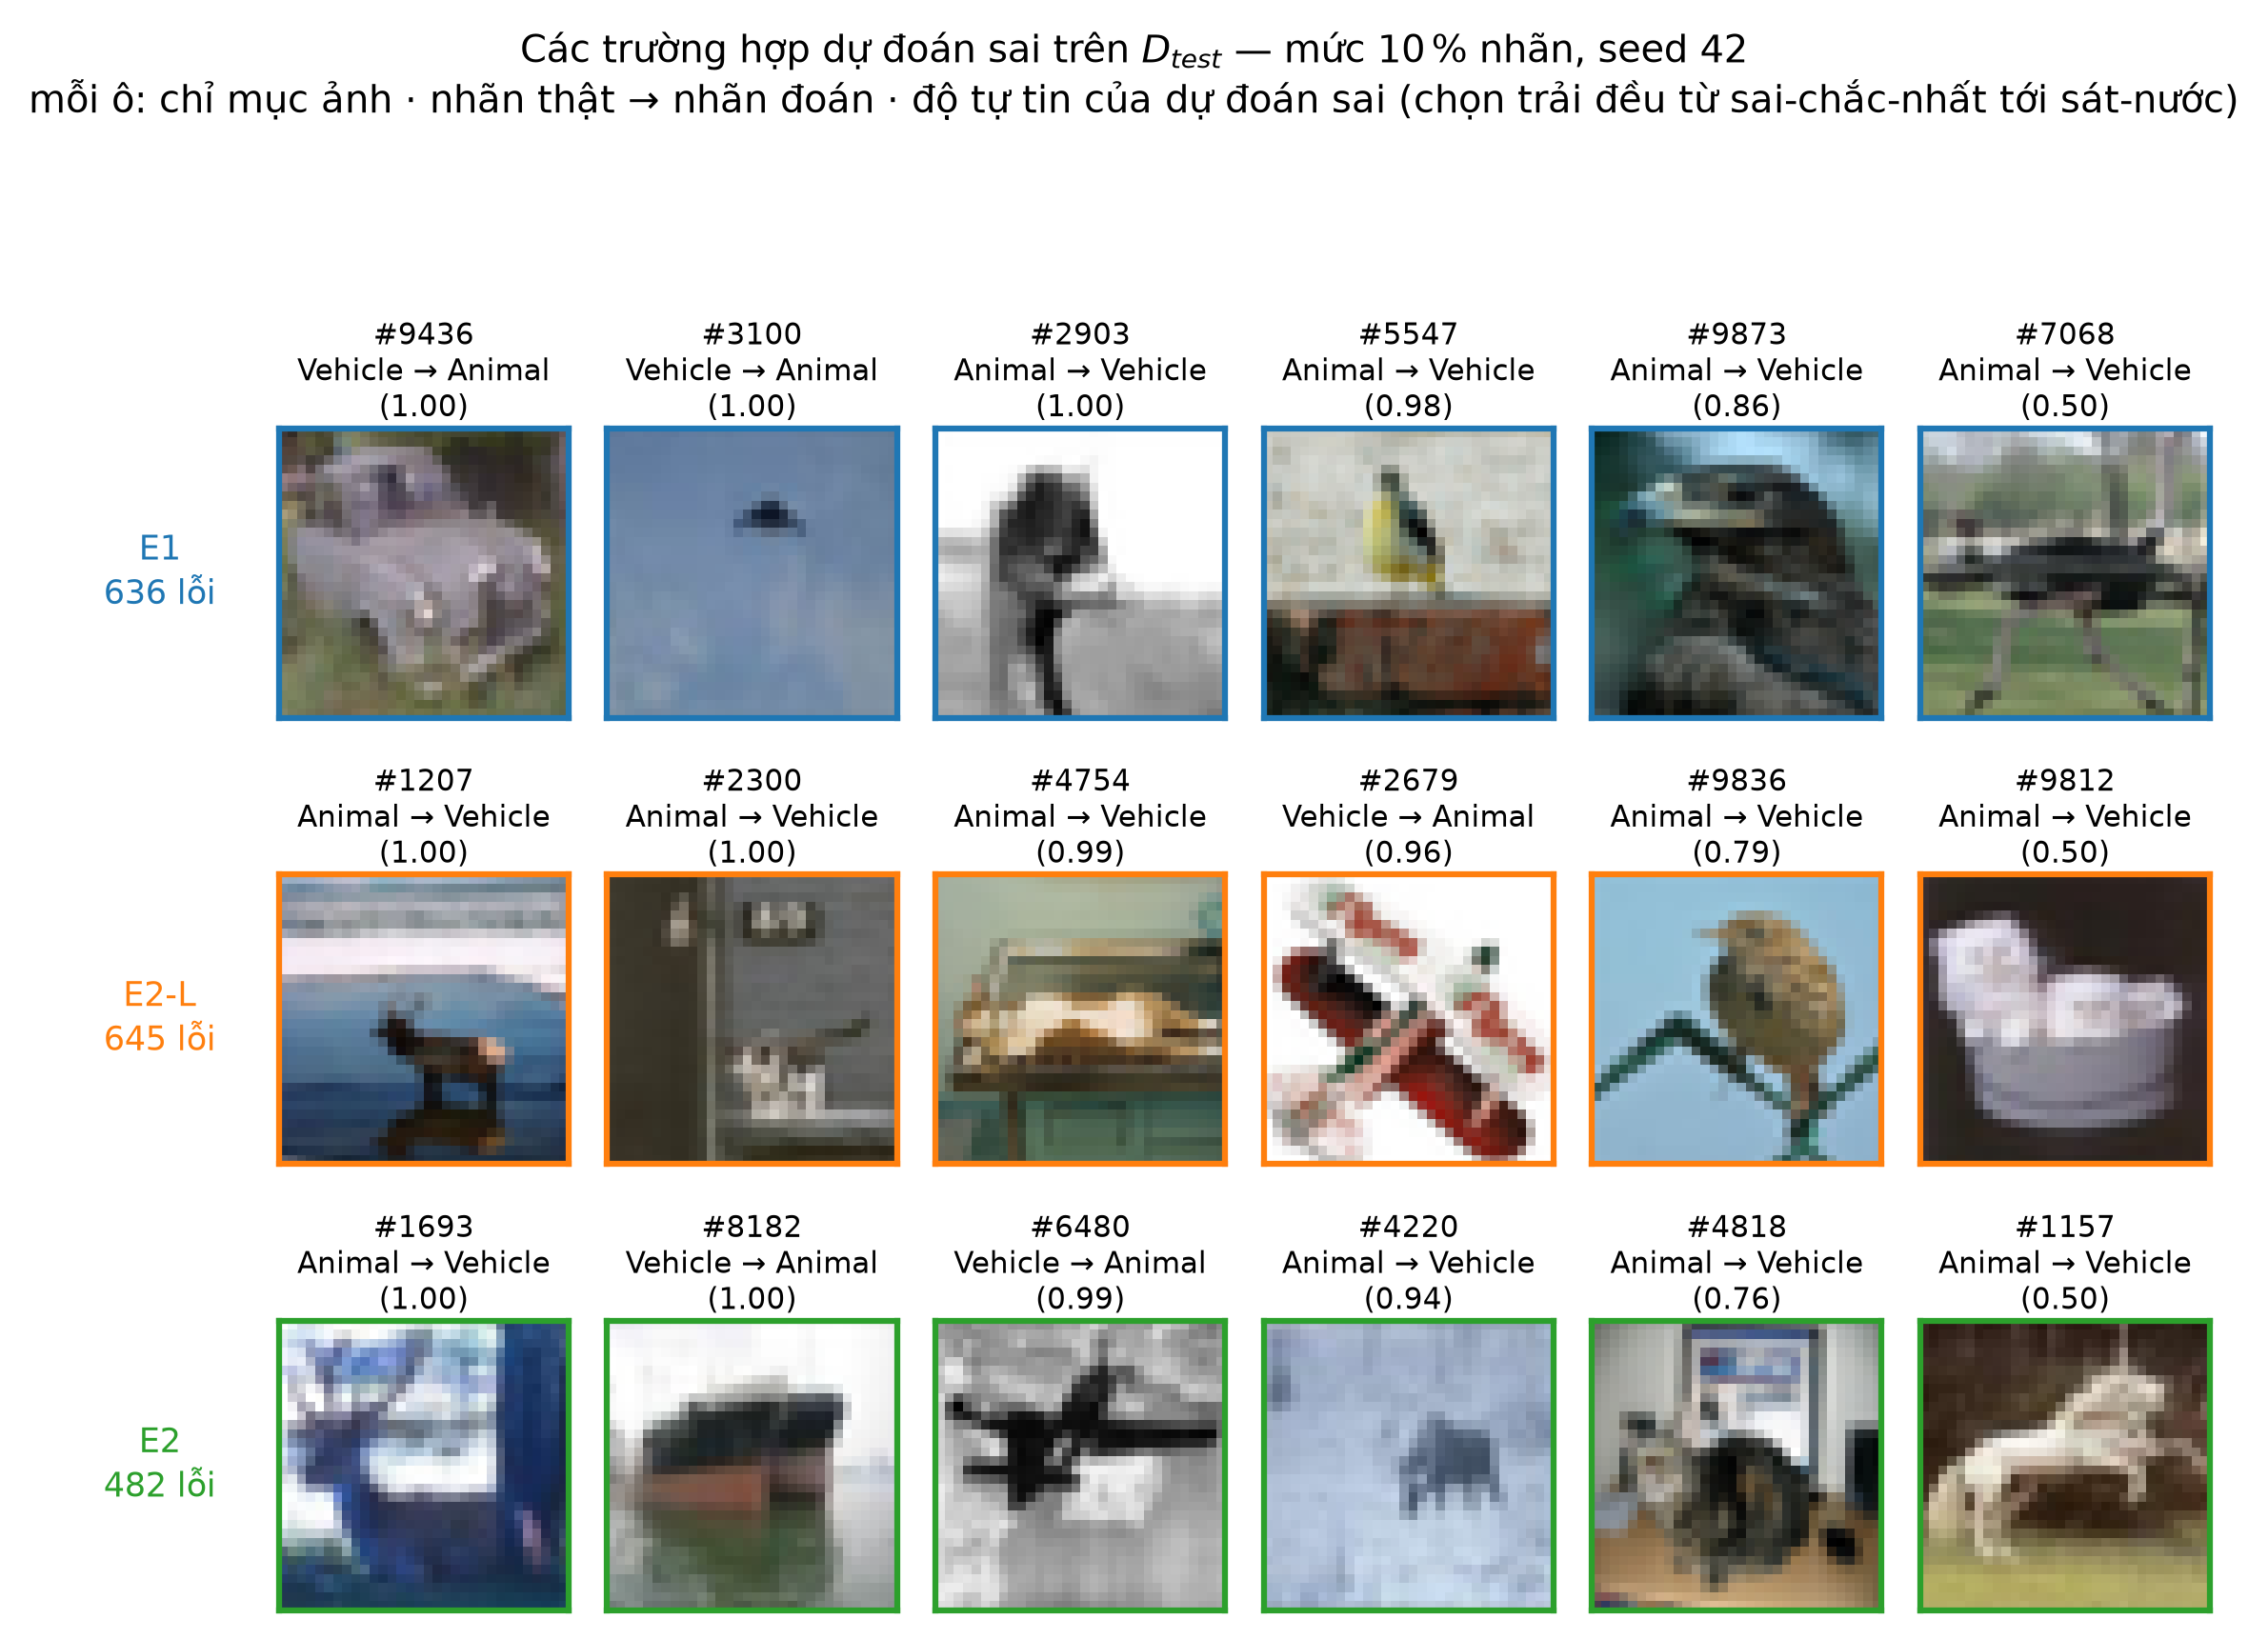

In [15]:
# Dự đoán test theo chỉ mục + hình các trường hợp dự đoán sai
PDIR = RES / "test_predictions"
preds = sorted(PDIR.glob("*.npz")) if PDIR.is_dir() else []
print(f"=== Dự đoán test theo chỉ mục: {len(preds)} lượt trong results/test_predictions/ ===")
if preds:
    from sklearn.metrics import f1_score
    rows = []
    for p in preds:
        d = np.load(p)
        rows.append({
            "lượt": p.stem,
            "n": len(d["y_true"]),
            "Macro-F1 tính lại": round(float(f1_score(d["y_true"], d["y_pred"],
                                                      average="macro")), 4),
            "Accuracy tính lại": round(float((d["y_true"] == d["y_pred"]).mean()), 4),
            "số ảnh sai": int((d["y_true"] != d["y_pred"]).sum()),
        })
    print(pd.DataFrame(rows).to_string(index=False))
    print()
    print("Mỗi tệp gồm: test_index (0..9999, thứ tự gốc, KHÔNG xáo trộn), y_true, y_pred,")
    print("logits (N,2) và prob (N,2) — đủ để người đọc tính lại mọi chỉ số trong báo cáo.")
    print("Ghi chú: các lượt E1/E2-L/E2 được CHẠY LẠI trên máy phân tích (cùng giao thức và")
    print("seed) vì gói bàn giao không kèm checkpoint khối chính; lệch cỡ 0,2 điểm phần trăm")
    print("so với bảng gốc do số học tích luỹ qua 100 epoch. Lượt E3/E4 khớp tuyệt đối.")
else:
    print("  (chưa có) — chạy: python scripts/run_error_analysis.py")

print()
print("### Hình các trường hợp dự đoán sai (mục 5.4 của báo cáo LaTeX)")
show_fig("fig09_misclassified_L10.png", width=1000)

## 9. Chẩn đoán nhánh phụ: Rotation Accuracy

Đây là **bằng chứng định lượng quan trọng nhất** của báo cáo — nó giải thích *vì sao* E2-L gần
như không khác E1. Rotation Accuracy đo trên $D_{val}$, đánh giá đủ bốn phép xoay cho mỗi ảnh.
**Mức đoán bừa là 25 %.**

In [16]:
rd_raw = load_json("rotation_diagnostic.json", {})
if rd_raw and rd_raw.get("rows"):
    rows = rd_raw["rows"]
    print(f"giao thức: {rd_raw.get('protocol')}")
    print()
    df_rd = pd.DataFrame(rows)
    print(df_rd.to_string(index=False))
    print()
    g = df_rd.groupby("config")["rotation_accuracy"].agg(["mean", "min", "max", "count"])
    print("=== Tổng hợp ===")
    print((g * 100).round(2).to_string())
    print()
    if "E2" in g.index and "E2-L" in g.index:
        print(f"  E2-L đạt {g.loc['E2-L','mean']*100:.1f} %  (kho ảnh 4.500)  -> Macro-F1 ≈ E1")
        print(f"  E2   đạt {g.loc['E2','mean']*100:.1f} %  (kho ảnh 45.000) -> Macro-F1 +1,51 pp")
        print()
        print("  KẾT LUẬN: nhánh phụ chỉ chuyển giao khi nó được HỌC ĐỦ TỐT, và nó chỉ học")
        print("  đủ tốt khi có đủ ẢNH. Ở 10 % nhãn, E2-L nhồi cùng 4.500 ảnh ~100 lần nên")
        print("  Rotation Accuracy chỉ ~62 %; E2 trải trên 45.000 ảnh ~10 lần nên đạt ~78 %.")
else:
    print("[!] chưa có results/rotation_diagnostic.json")
    print("    Chạy: python scripts/run_rotation_diagnostic.py")

giao thức: đánh giá đủ 4 phép xoay cho mỗi ảnh validation

         tag config  label_pct  seed  rotation_accuracy
E2-L_L10_s42   E2-L         10    42            0.63225
E2-L_L10_s43   E2-L         10    43            0.61775
E2-L_L10_s44   E2-L         10    44            0.61220
  E2_L10_s42     E2         10    42            0.79290
  E2_L10_s43     E2         10    43            0.78375
  E2_L10_s44     E2         10    44            0.77640

=== Tổng hợp ===
         mean    min    max  count
config                            
E2      78.44  77.64  79.29    300
E2-L    62.07  61.22  63.22    300

  E2-L đạt 62.1 %  (kho ảnh 4.500)  -> Macro-F1 ≈ E1
  E2   đạt 78.4 %  (kho ảnh 45.000) -> Macro-F1 +1,51 pp

  KẾT LUẬN: nhánh phụ chỉ chuyển giao khi nó được HỌC ĐỦ TỐT, và nó chỉ học
  đủ tốt khi có đủ ẢNH. Ở 10 % nhãn, E2-L nhồi cùng 4.500 ảnh ~100 lần nên
  Rotation Accuracy chỉ ~62 %; E2 trải trên 45.000 ảnh ~10 lần nên đạt ~78 %.


## 10. Chi phí huấn luyện và suy luận

Chi phí **suy luận** là chi phí quyết định trên thiết bị biên: mô hình được huấn luyện một lần
trên máy chủ nhưng chạy liên tục trên thiết bị. Điểm mấu chốt: **E1 và E2 có kiến trúc suy luận
giống hệt nhau** — Rotation Head bị bỏ hoàn toàn khi suy luận.

In [17]:
ib = load_json("inference_benchmark.json", {})
if ib:
    p = ib.get("parameters", {})
    print("=== Tham số và dung lượng ===")
    print(f"  encoder              : {p.get('encoder'):>12,}")
    print(f"  Superclass Head      : {p.get('super_head'):>12,}")
    print(f"  Rotation Head        : {p.get('rotation_head'):>12,}  (chỉ khi huấn luyện)")
    print(f"  suy luận             : {p.get('inference_total'):>12,}  "
          f"= {p.get('inference_fp32_mib', 0):.2f} MiB FP32")
    print(f"  huấn luyện           : {p.get('training_total'):>12,}")
    print(f"  tệp trọng số đo được : {p.get('inference_file_mib', 0):.2f} MiB")
    print()
    print("=== Độ trễ batch=1, tensor 1x3x32x32, FP32, inference_mode() ===")
    print(f"  {'điều kiện':28s}{'mean':>9s}{'median':>9s}{'p95':>9s}  (ms/ảnh)")
    for key, label in (("latency_cpu", "CPU (4 luồng)"),
                       ("latency_gpu", f"GPU {ib.get('environment',{}).get('gpu','')[:22]}")):
        v = ib.get(key)
        if v:
            print(f"  {label:28s}{v['mean_ms']:>9.3f}{v['median_ms']:>9.3f}{v['p95_ms']:>9.3f}")
    print()
    print("  LƯU Ý cách tổng hợp: mean và p95 là TRUNG BÌNH của ba phiên, còn median là")
    print("  TRUNG VỊ CỦA BA TRUNG VỊ phiên (xem src/m8/benchmark.py).")
    pp = ib.get("preprocess_ms_per_image")
    if pp:
        print(f"  tiền xử lý CPU đo riêng : {pp} ms/ảnh")
else:
    print("[!] chưa có results/inference_benchmark.json")
    print("    Chạy: python scripts/run_inference_benchmark.py")

=== Tham số và dung lượng ===
  encoder              :   11,168,832
  Superclass Head      :        1,026
  Rotation Head        :        2,052  (chỉ khi huấn luyện)
  suy luận             :   11,169,858  = 42.61 MiB FP32
  huấn luyện           :   11,171,910
  tệp trọng số đo được : 42.68 MiB

=== Độ trễ batch=1, tensor 1x3x32x32, FP32, inference_mode() ===
  điều kiện                        mean   median      p95  (ms/ảnh)
  CPU (4 luồng)                   7.012    6.866    9.466
  GPU NVIDIA GeForce RTX 507      2.701    2.062    5.870

  LƯU Ý cách tổng hợp: mean và p95 là TRUNG BÌNH của ba phiên, còn median là
  TRUNG VỊ CỦA BA TRUNG VỊ phiên (xem src/m8/benchmark.py).
  tiền xử lý CPU đo riêng : 0.13176269544601382 ms/ảnh


In [18]:
if not df_runs.empty:
    print("=== Chi phí huấn luyện (giây/lượt, 100 epoch) ===")
    t = df_runs.pivot_table(index="config", columns="label_pct",
                            values="train_seconds", aggfunc="mean").round(1)
    t = t.reindex([c for c in ("E1", "E2-L", "E2") if c in t.index])
    print(t.to_string())
    if {"E1", "E2-L", "E2"}.issubset(set(t.index)):
        print()
        print("=== Tỷ lệ thời gian ===")
        print("  E2 / E1  :", (t.loc["E2"] / t.loc["E1"]).round(3).to_dict())
        print("  E2 / E2-L:", (t.loc["E2"] / t.loc["E2-L"]).round(4).to_dict())
        print()
        print("  KẾT LUẬN QUAN TRỌNG: E2 và E2-L có chi phí huấn luyện GẦN NHƯ BẰNG NHAU")
        print("  (tỷ lệ ≈ 1,00). Số view của nhánh phụ mỗi epoch do kích thước B_L quyết")
        print("  định, KHÔNG do kích thước kho rút mẫu. Vì vậy mở rộng kho ảnh cho nhánh xoay")
        print("  từ 4.500 lên 45.000 ảnh gần như MIỄN PHÍ về thời gian huấn luyện.")
        rc = load_json("rotation_data_cost.json", {})
        if rc:
            print()
            print("  (rotation_data_cost.json đo theo GIẢ ĐỊNH nhánh phụ duyệt hết tập nguồn")
            print("   mỗi epoch; trong mã nguồn B_R bị cắt về đúng b_L, nên con số thực thấp hơn.)")

=== Chi phí huấn luyện (giây/lượt, 100 epoch) ===
label_pct     10      20      50
config                          
E1         344.1   557.9  1165.4
E2-L       575.6  1026.8  2322.4
E2         578.8  1013.9  2322.3

=== Tỷ lệ thời gian ===
  E2 / E1  : {10: 1.682, 20: 1.817, 50: 1.993}
  E2 / E2-L: {10: 1.0056, 20: 0.9874, 50: 1.0}

  KẾT LUẬN QUAN TRỌNG: E2 và E2-L có chi phí huấn luyện GẦN NHƯ BẰNG NHAU
  (tỷ lệ ≈ 1,00). Số view của nhánh phụ mỗi epoch do kích thước B_L quyết
  định, KHÔNG do kích thước kho rút mẫu. Vì vậy mở rộng kho ảnh cho nhánh xoay
  từ 4.500 lên 45.000 ảnh gần như MIỄN PHÍ về thời gian huấn luyện.



  (rotation_data_cost.json đo theo GIẢ ĐỊNH nhánh phụ duyệt hết tập nguồn
   mỗi epoch; trong mã nguồn B_R bị cắt về đúng b_L, nên con số thực thấp hơn.)


## 11. Hình minh hoạ và hình kết quả

Ảnh CIFAR chỉ **32×32 px**, nên mọi hình minh hoạ dữ liệu phải dùng nội suy `nearest` — nội suy
làm mượt sẽ biến ảnh thành nhoè. Các hình dưới đây sinh bằng `scripts/make_dataset_figures.py`
và `scripts/make_figures.py` ở 300 DPI.

### Hình A1 — CIFAR-10 theo 10 lớp gốc và phép gộp hai siêu lớp


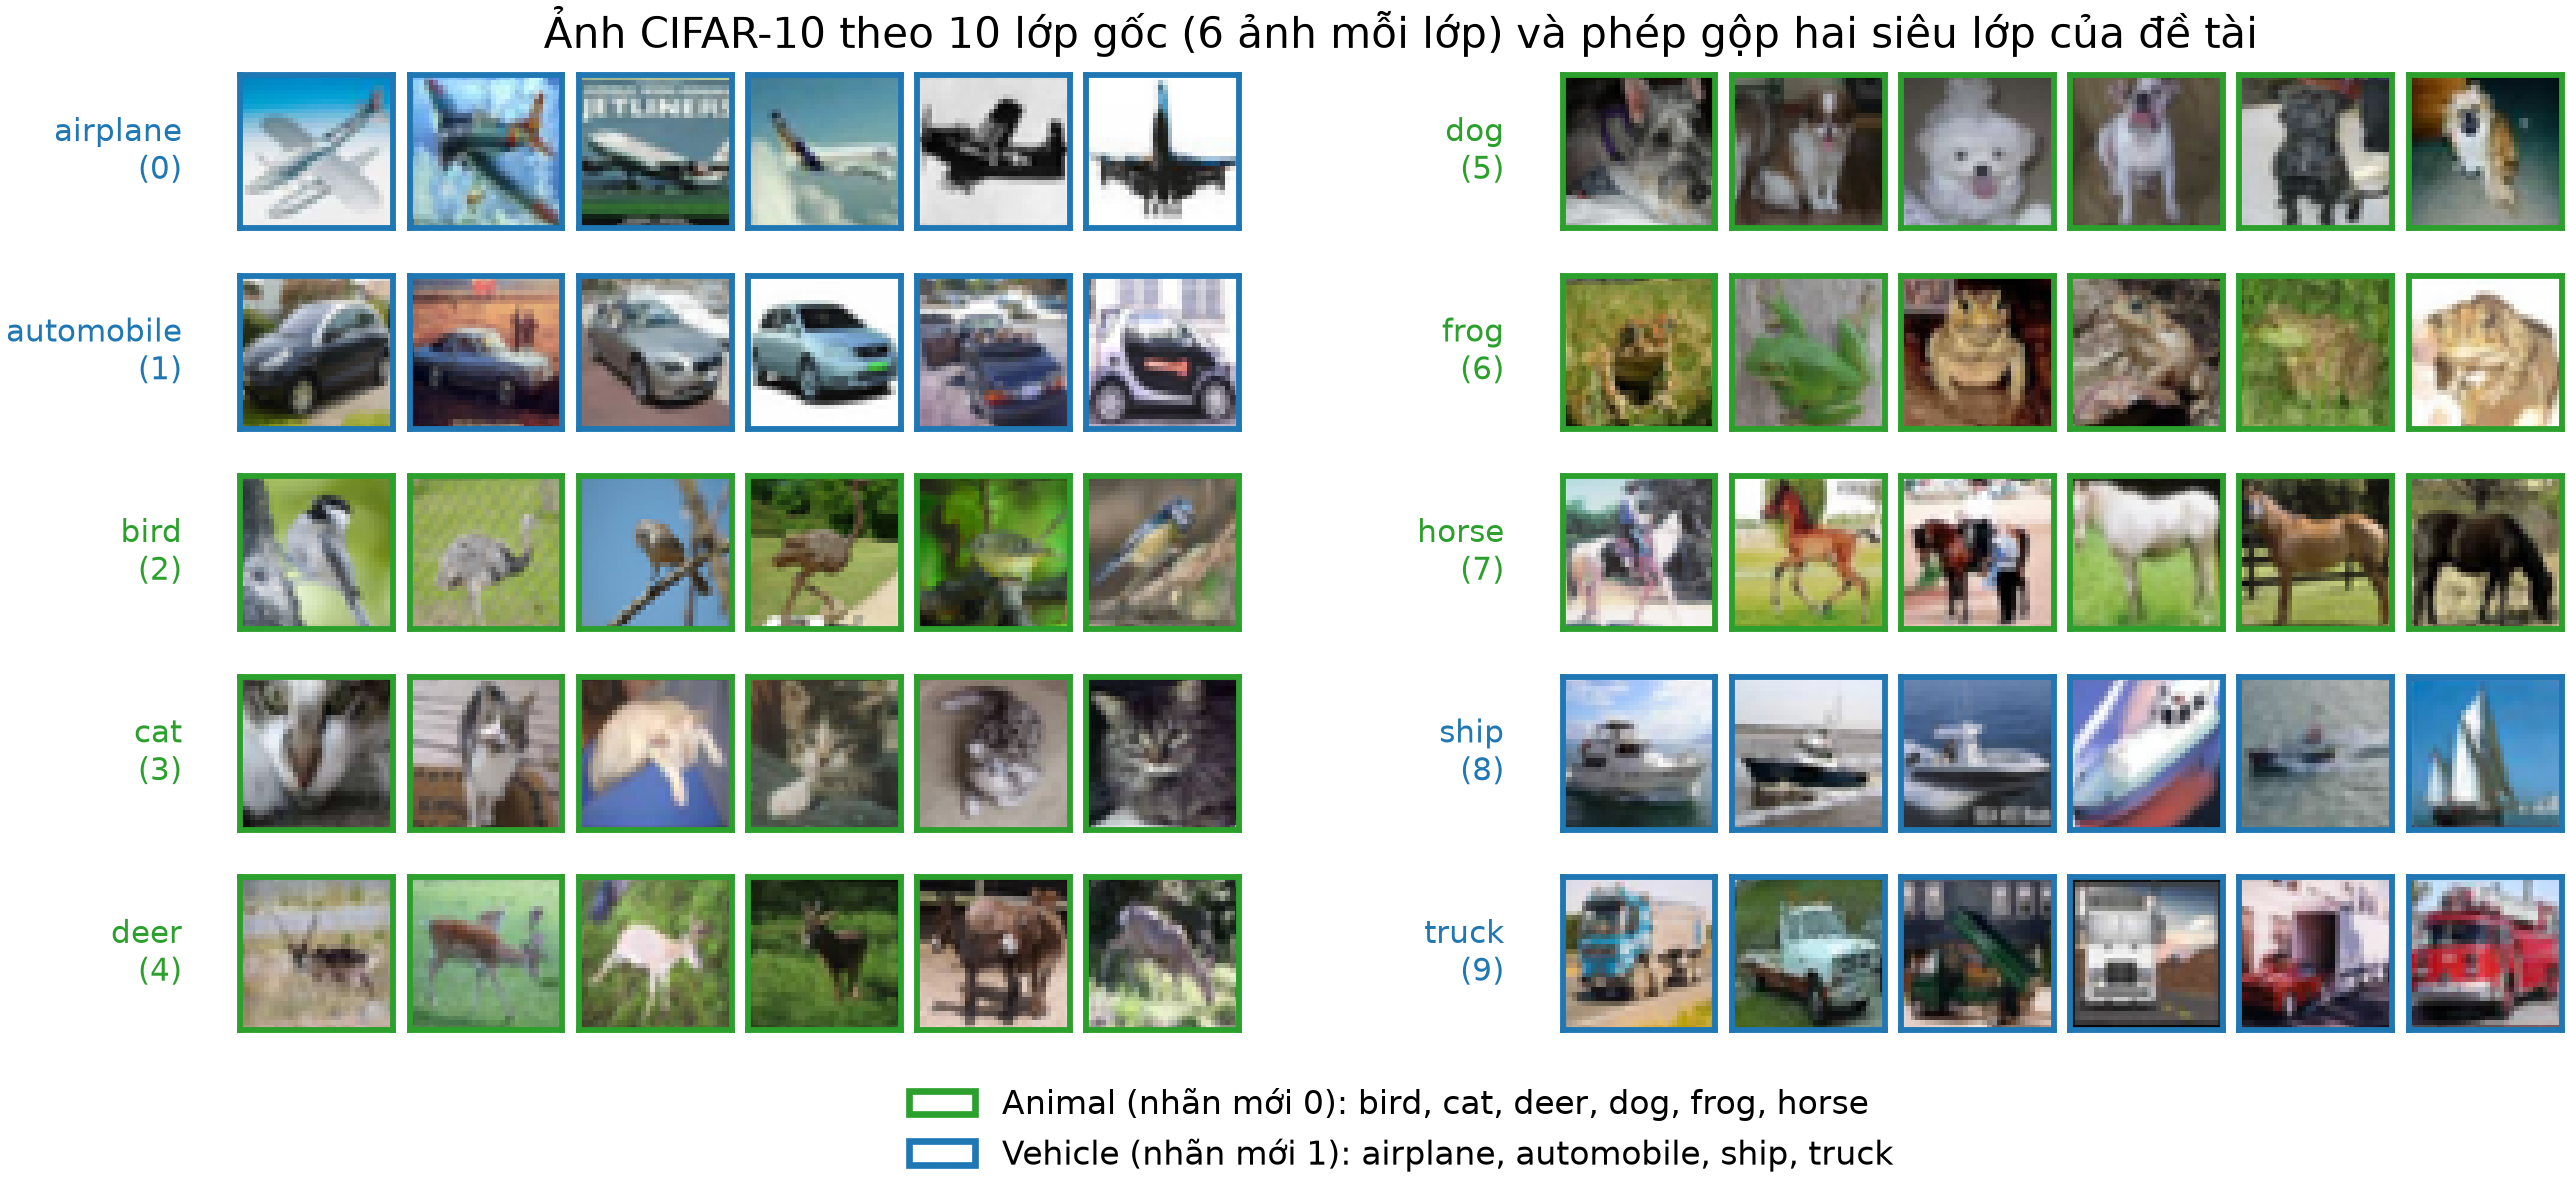


### Hình A2 — Thành phần dữ liệu của phép chia benchmark


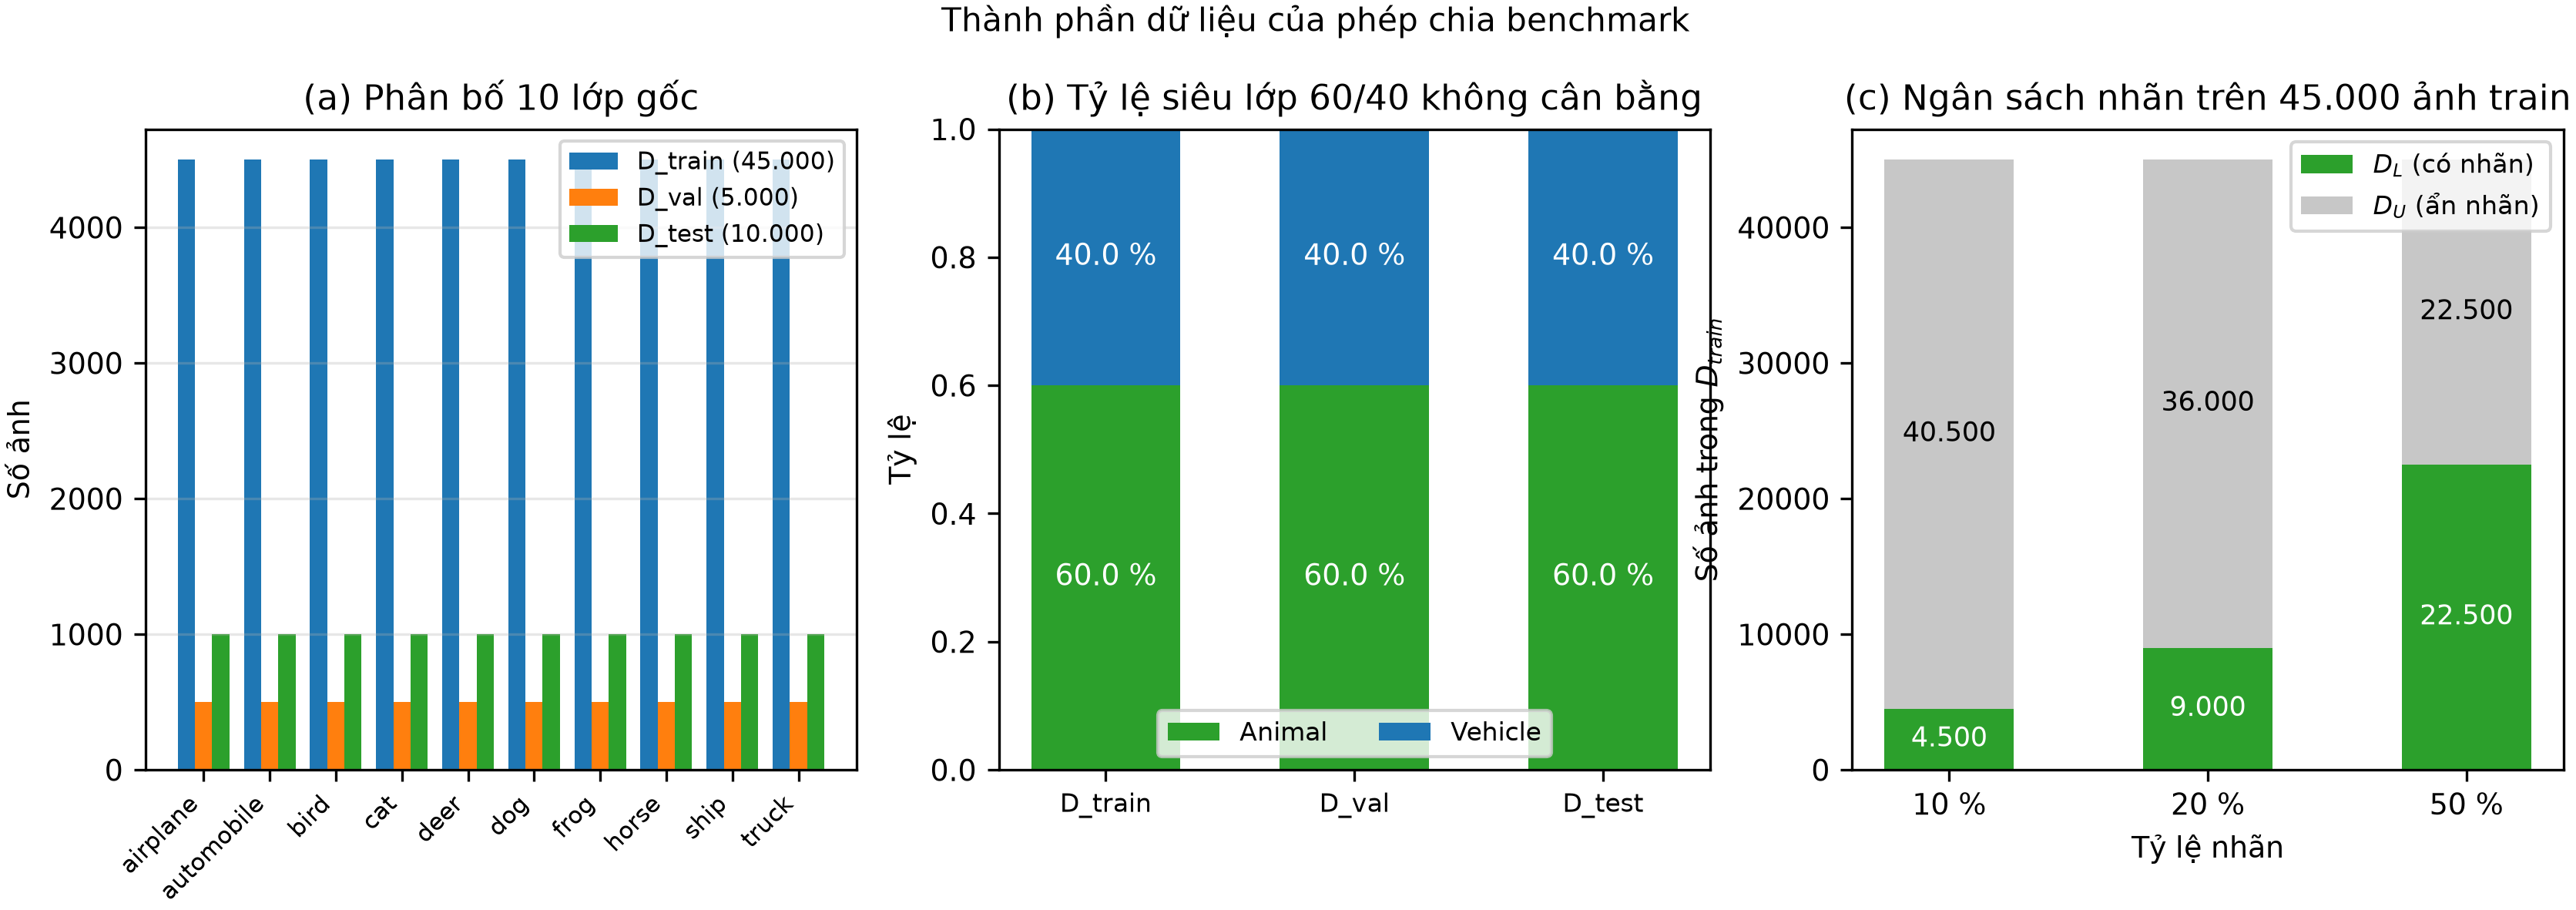

In [19]:
print("### Hình A1 — CIFAR-10 theo 10 lớp gốc và phép gộp hai siêu lớp")
show_fig("figA1_dataset_samples.png")
print()
print("### Hình A2 — Thành phần dữ liệu của phép chia benchmark")
show_fig("figA2_class_distribution.png")

### Hình A3 — Ba loại view của cùng một ảnh (phân loại / contrastive / xoay)


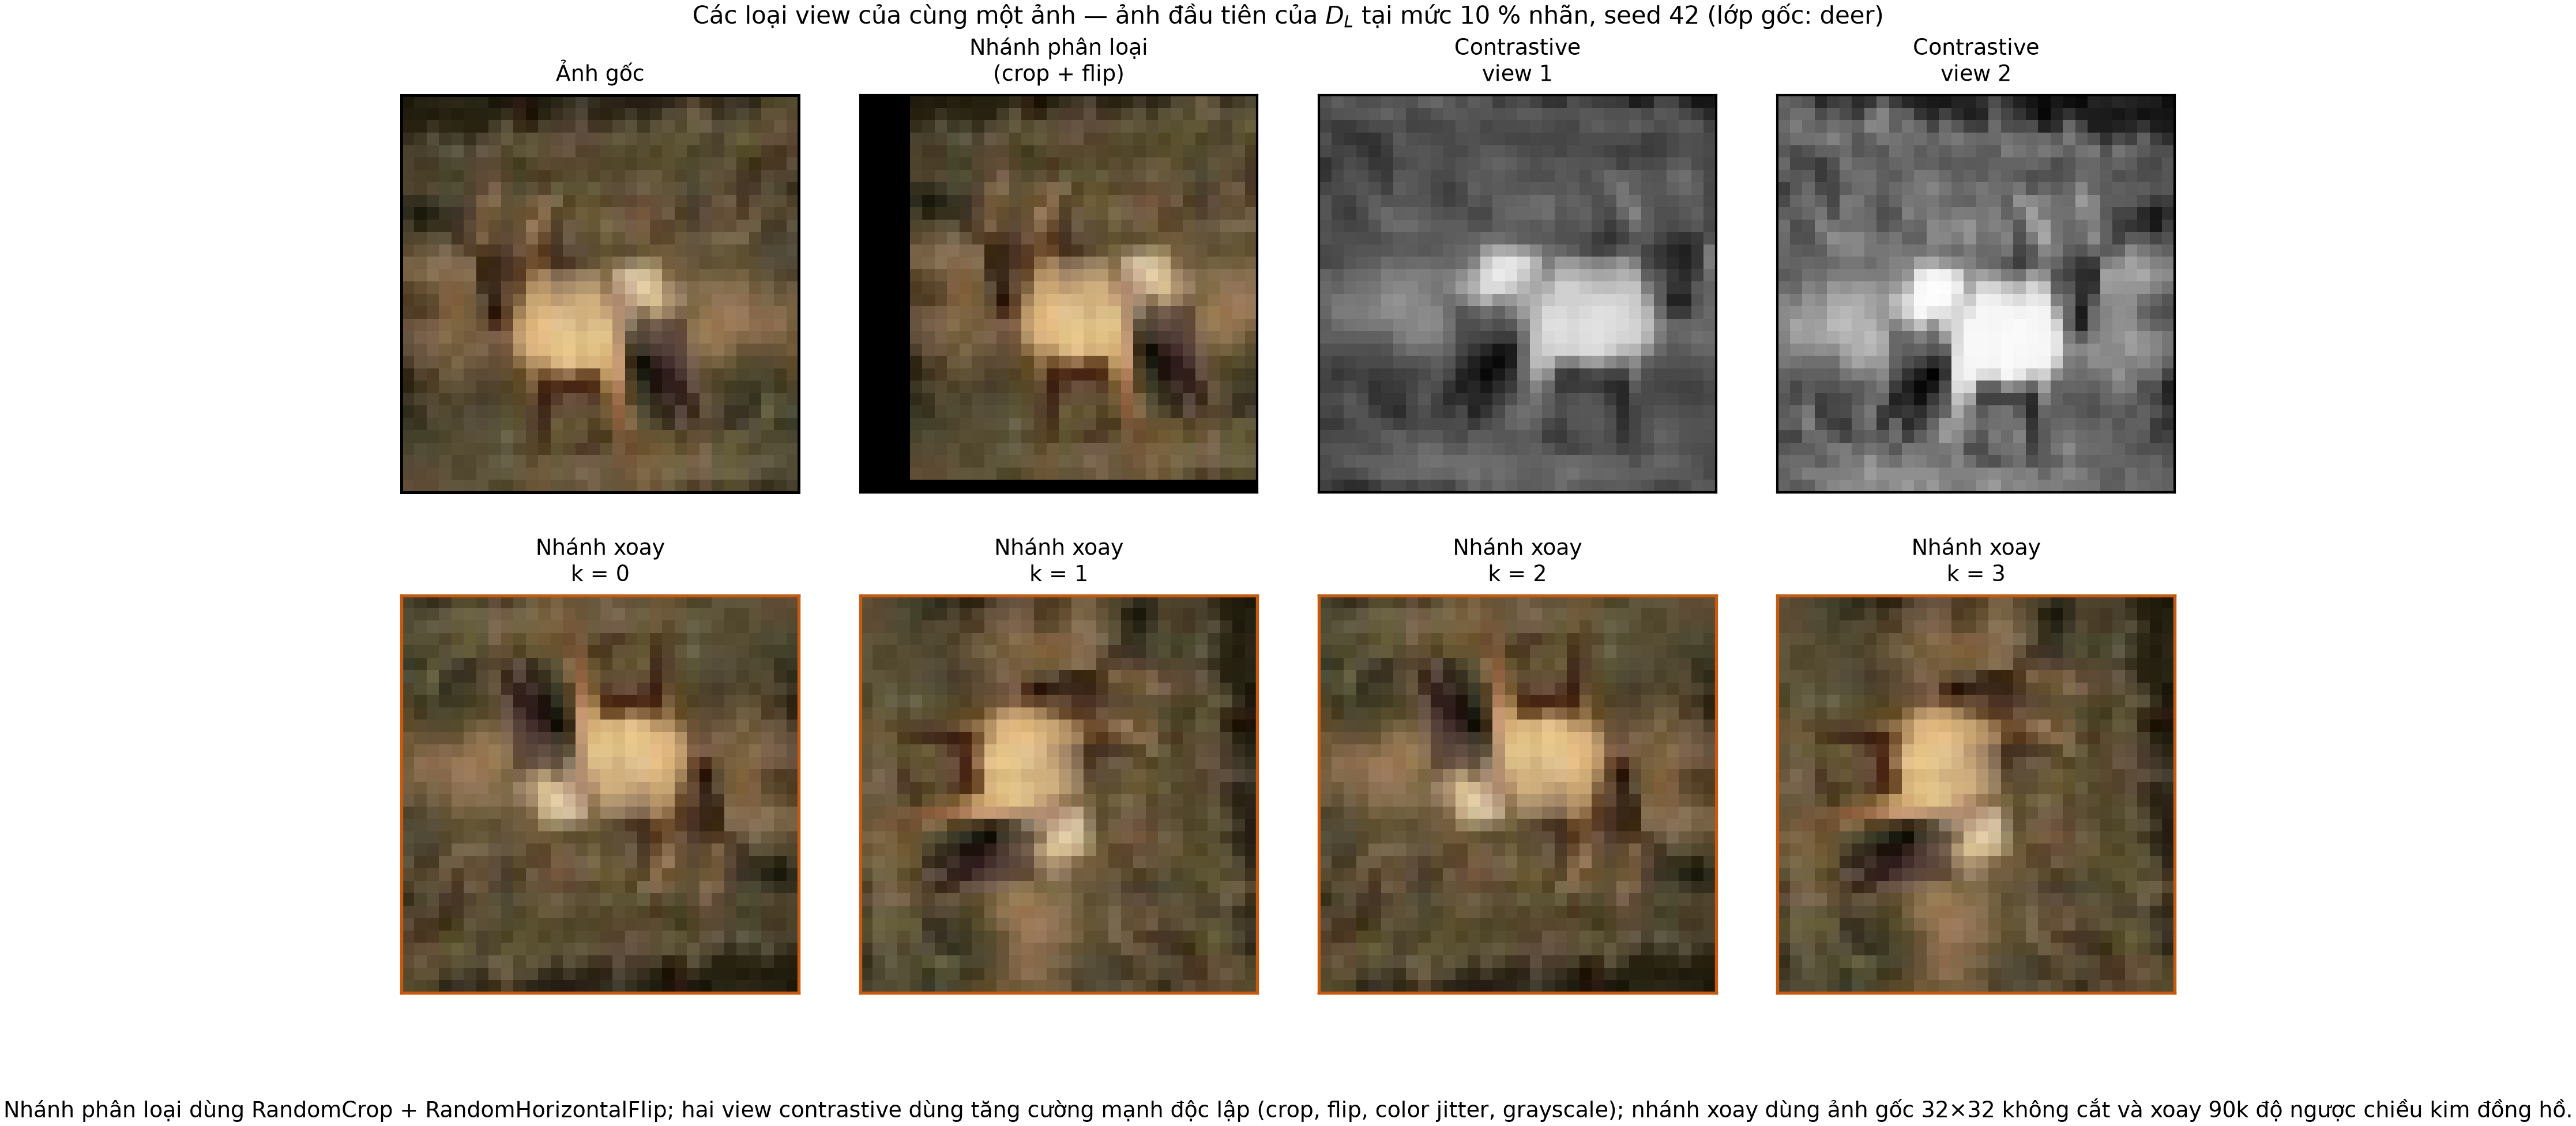

In [20]:
print("### Hình A3 — Ba loại view của cùng một ảnh (phân loại / contrastive / xoay)")
show_fig("figA3_views.png")

### Hình kết quả khối chính

**Macro-F1 theo ngân sách nhãn**


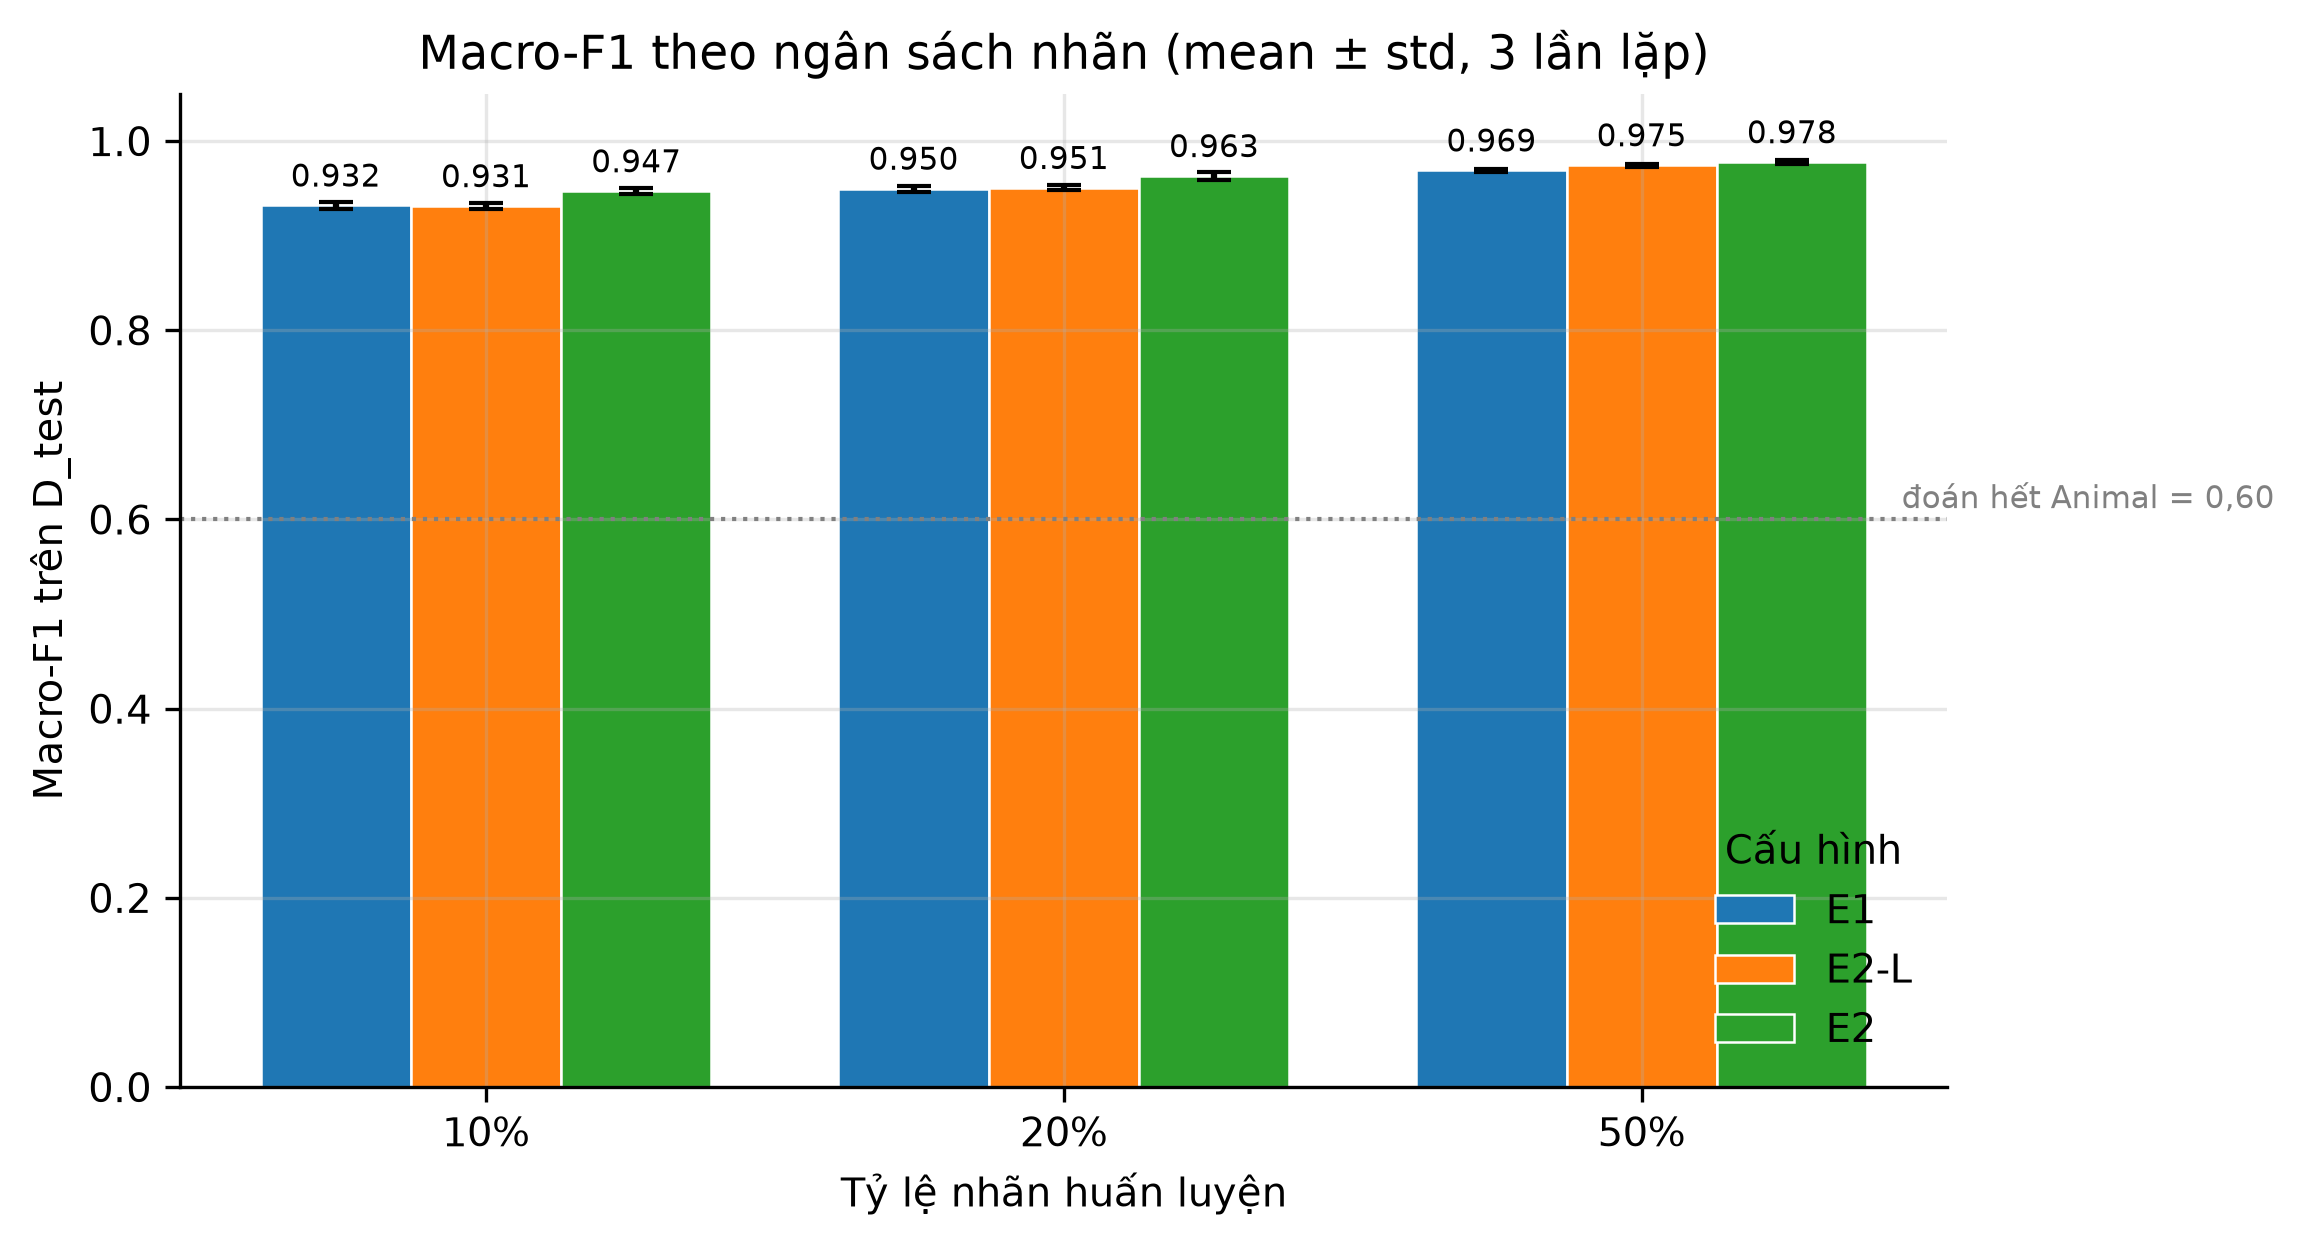


**Chênh lệch ghép cặp so với E1**


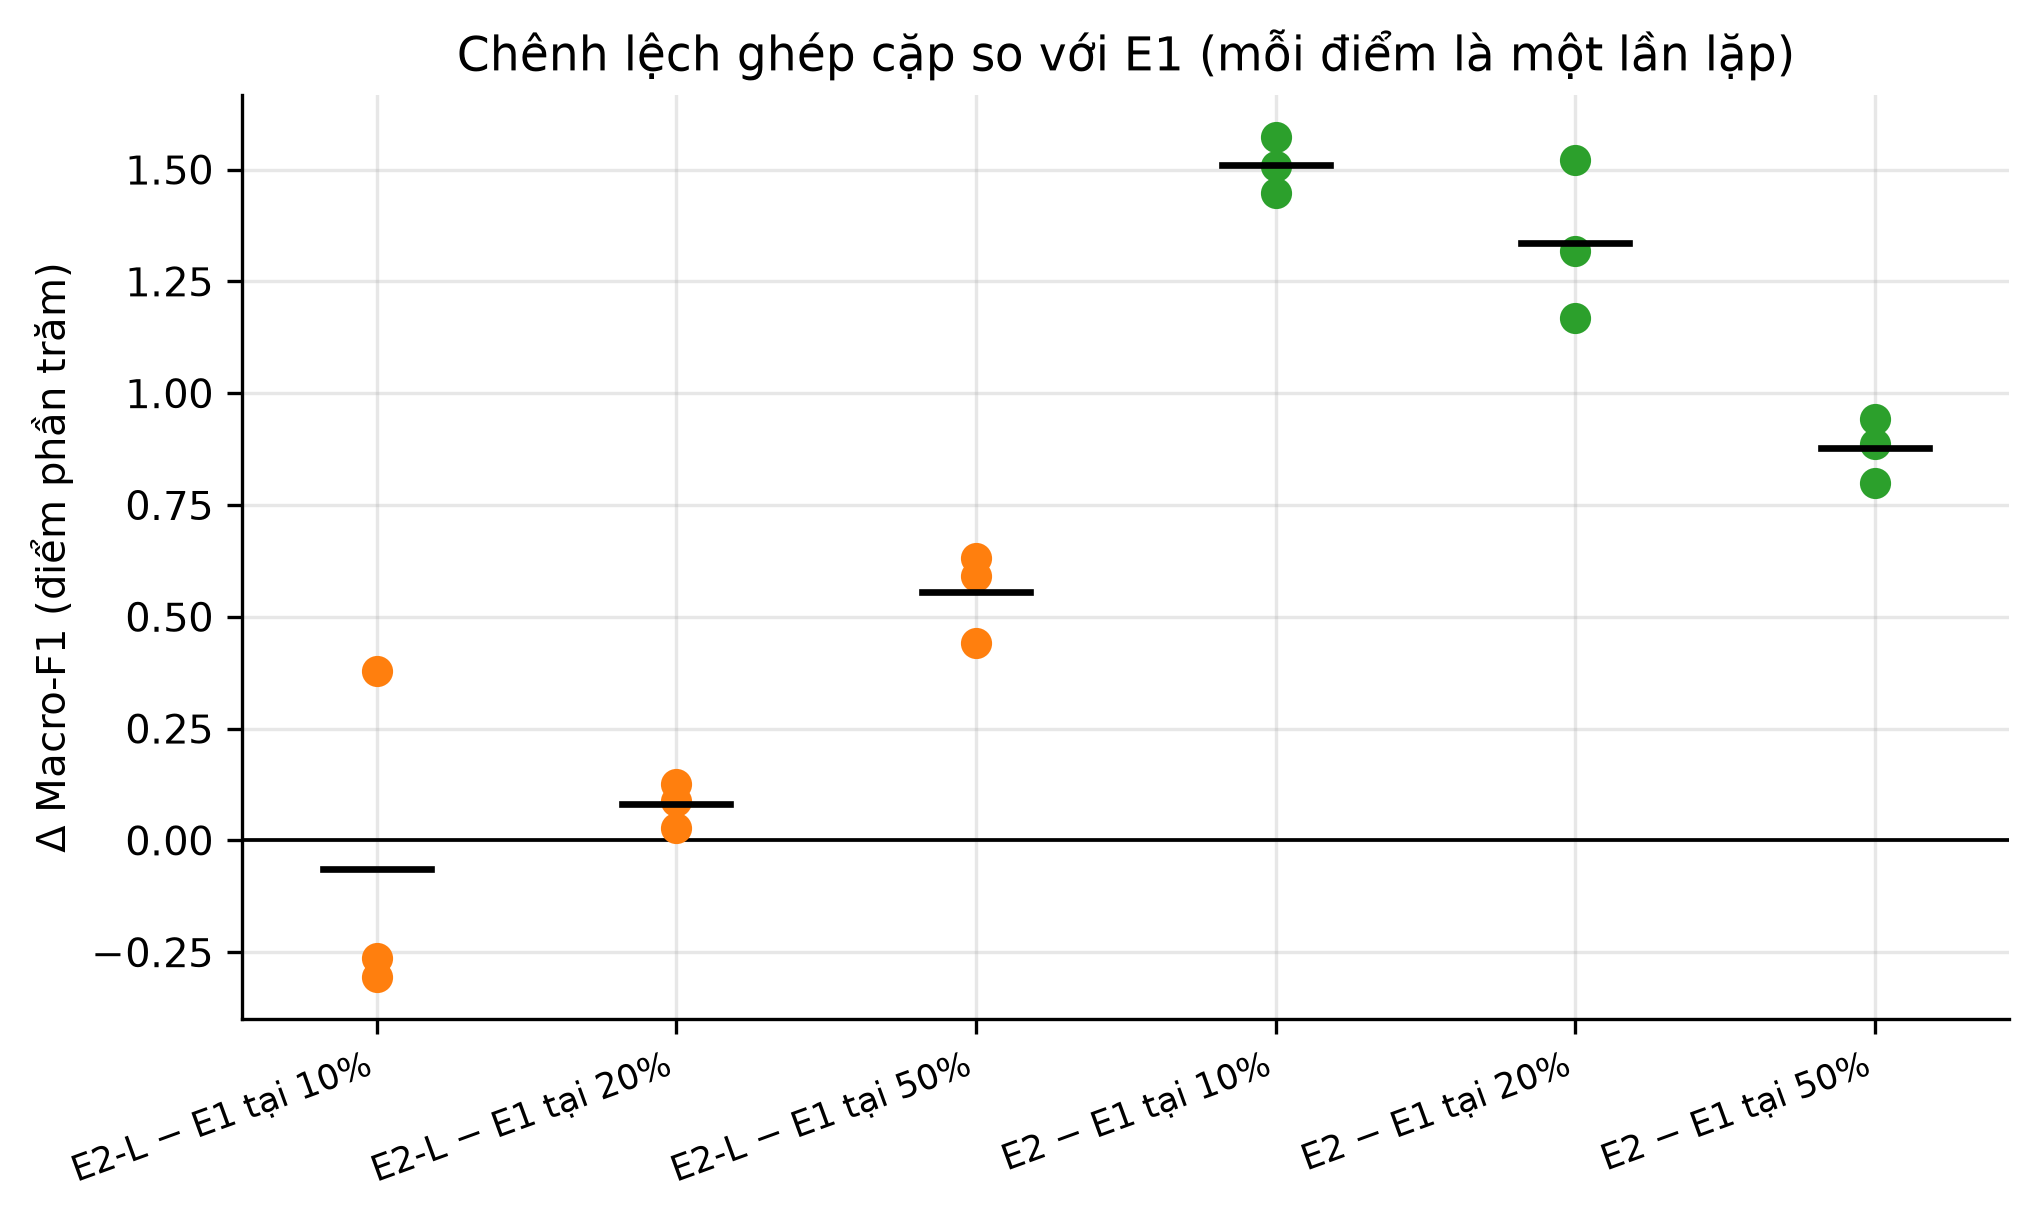


**Ma trận nhầm lẫn tại 10 % nhãn**


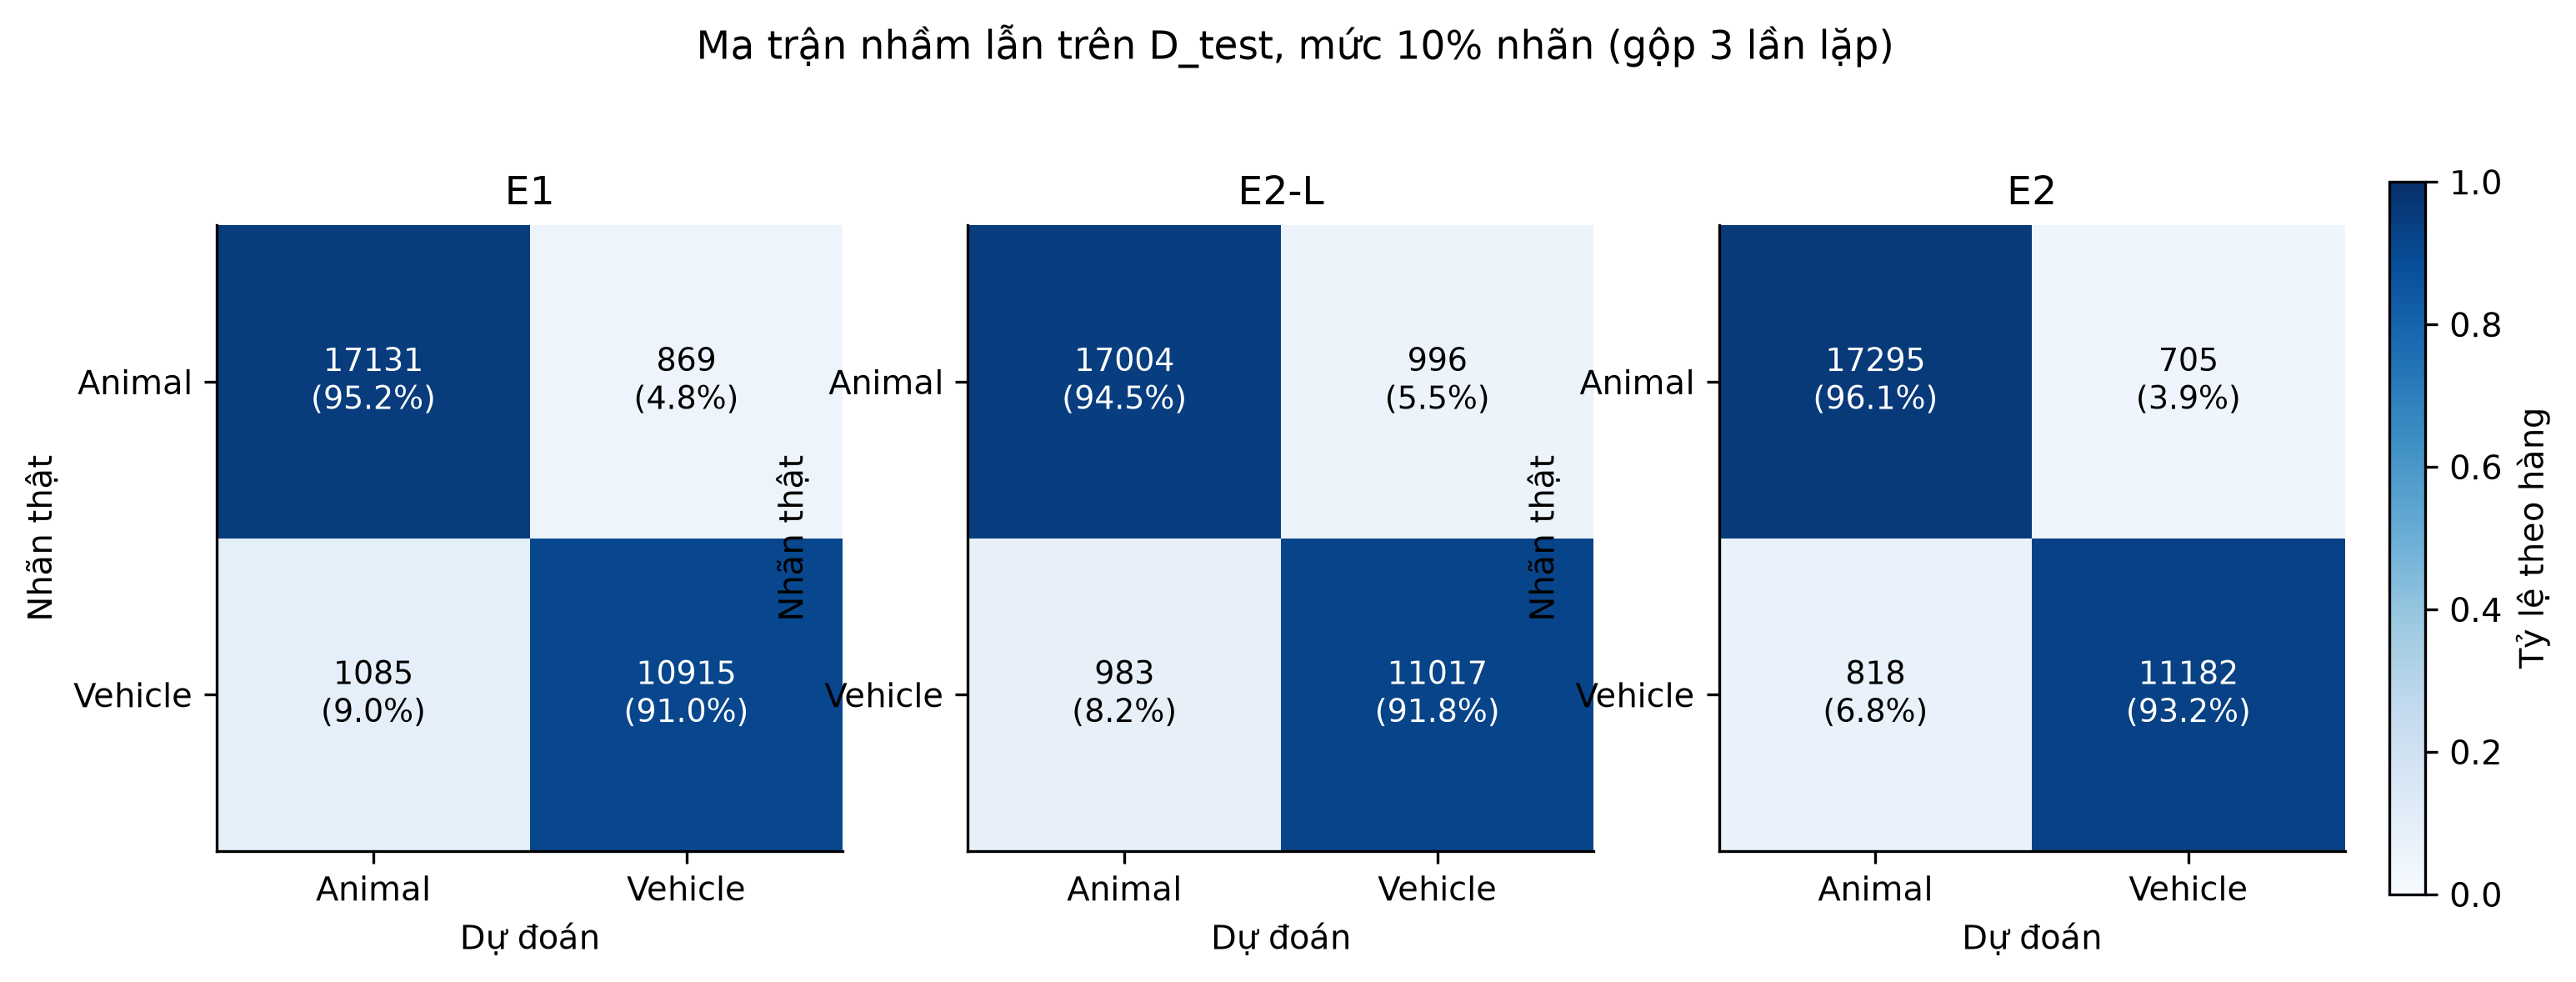


**Đường học tại 10 % nhãn**


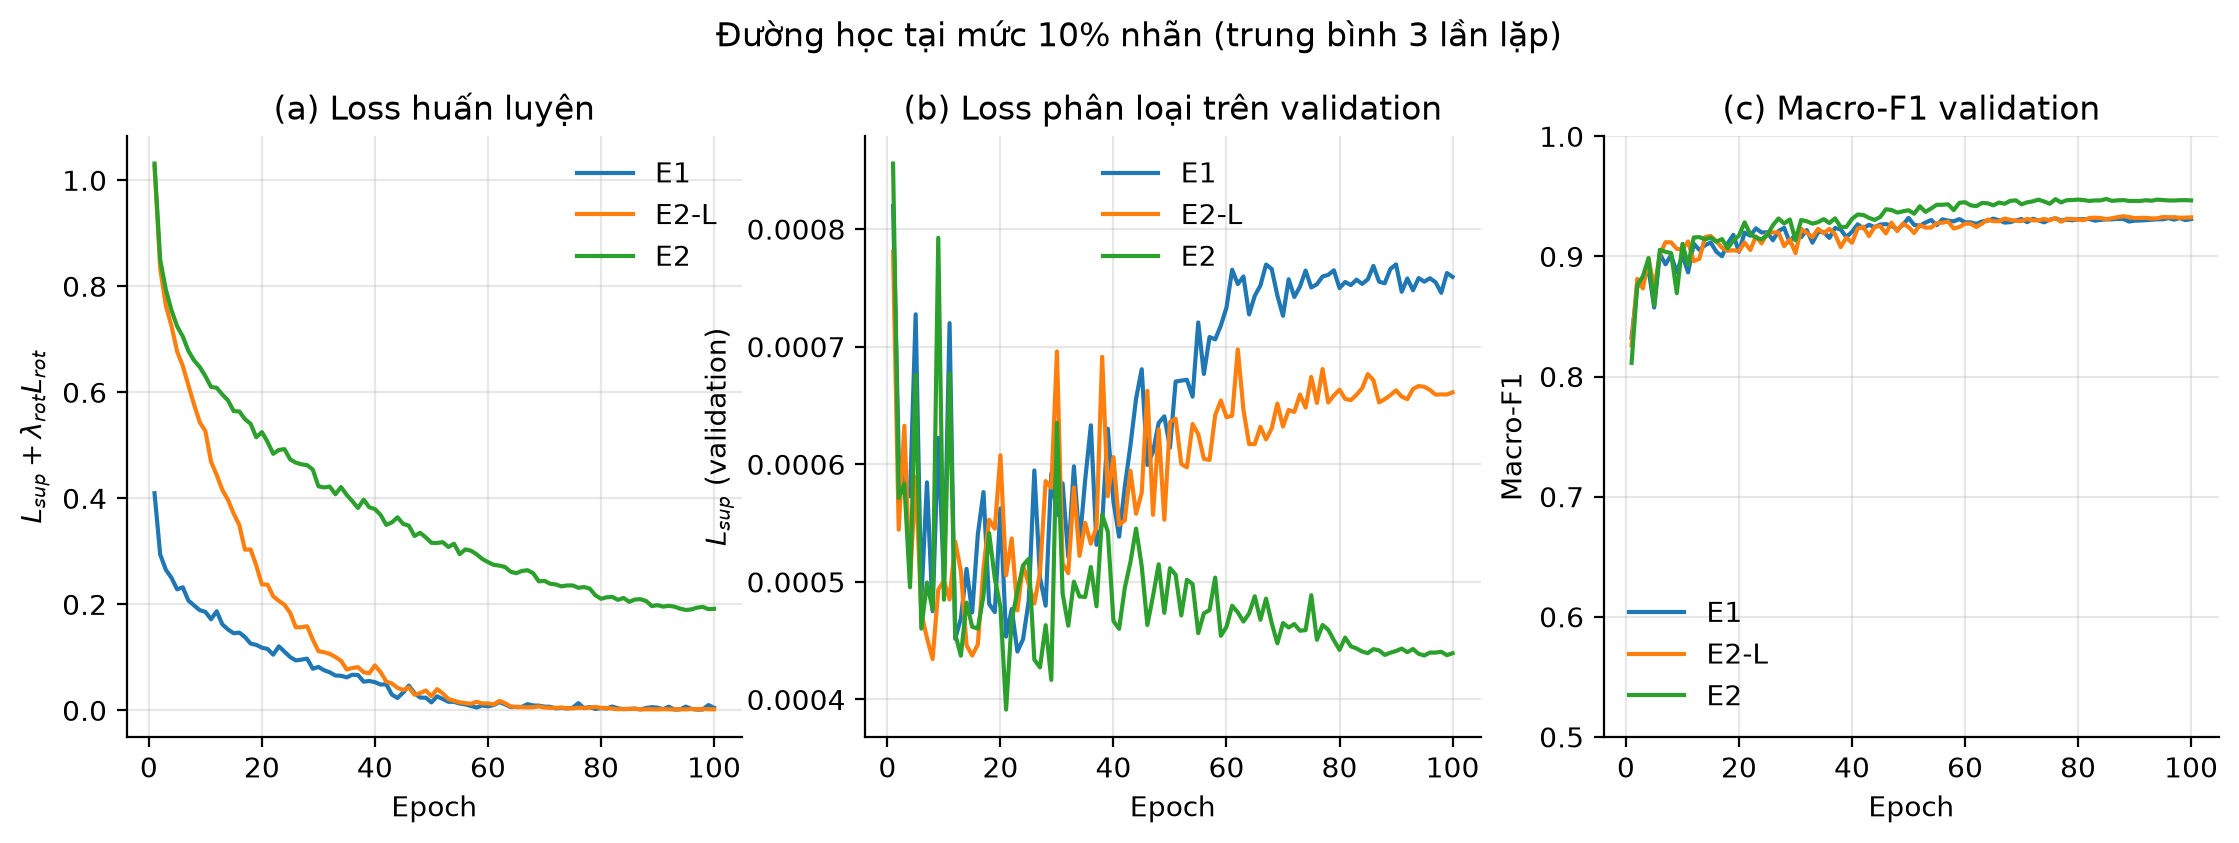

In [21]:
print("### Hình kết quả khối chính")
for f, cap in [("fig02_macro_f1_by_budget.png", "Macro-F1 theo ngân sách nhãn"),
               ("fig03_paired_delta.png", "Chênh lệch ghép cặp so với E1"),
               ("fig04_confusion_L10.png", "Ma trận nhầm lẫn tại 10 % nhãn"),
               ("fig01_learning_curves_L10.png", "Đường học tại 10 % nhãn")]:
    print(f"\n**{cap}**")
    show_fig(f, width=820)

### Hình khối mở rộng (nếu đã chạy)

**Khảo sát lambda_c — CHỈ trên validation**


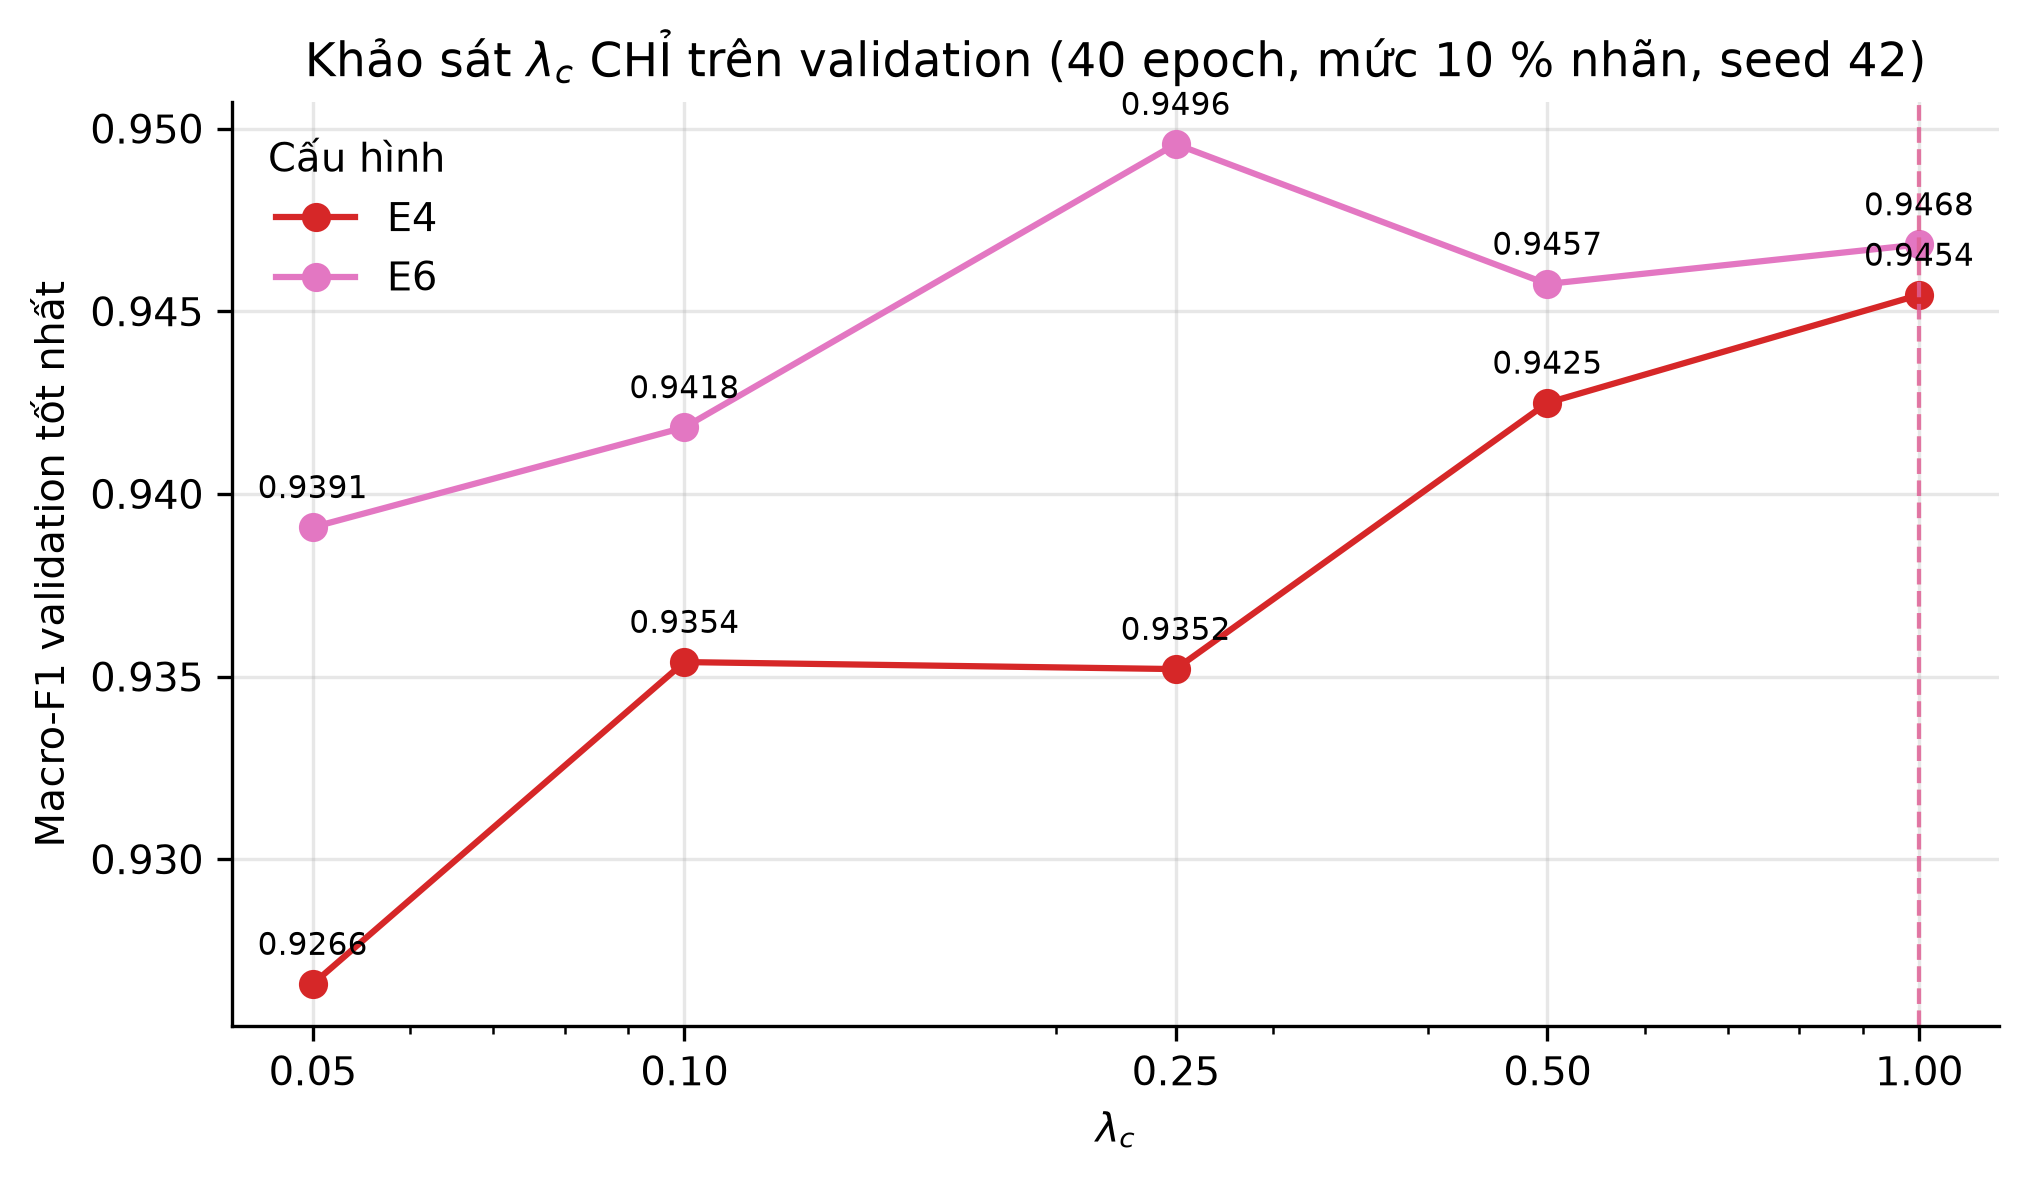


**Macro-F1 khối chính và mở rộng**


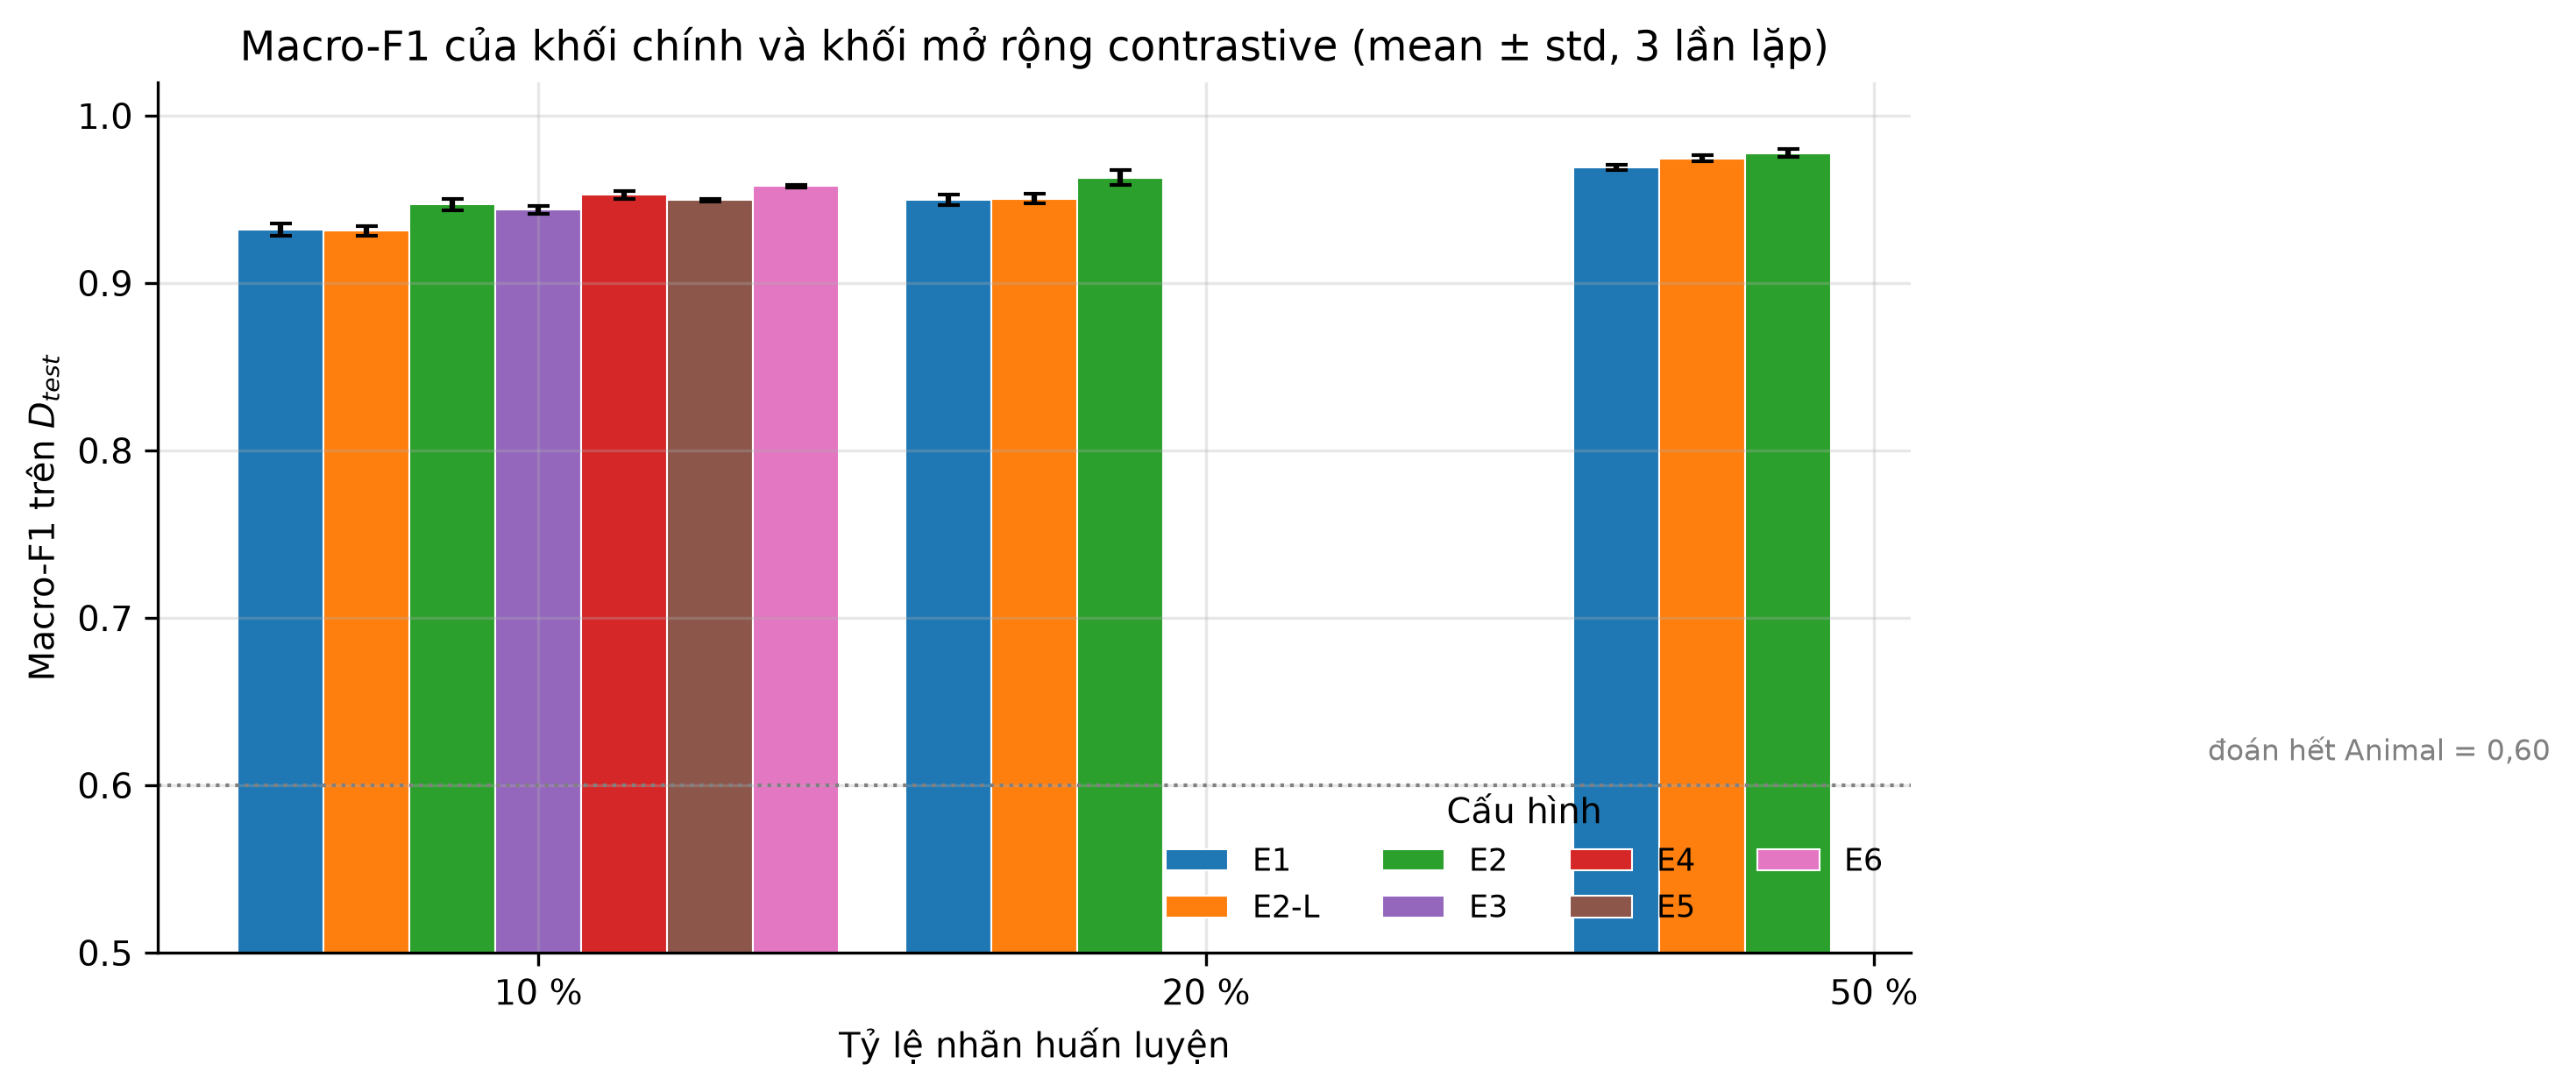


**Chênh lệch ghép cặp của khối mở rộng**


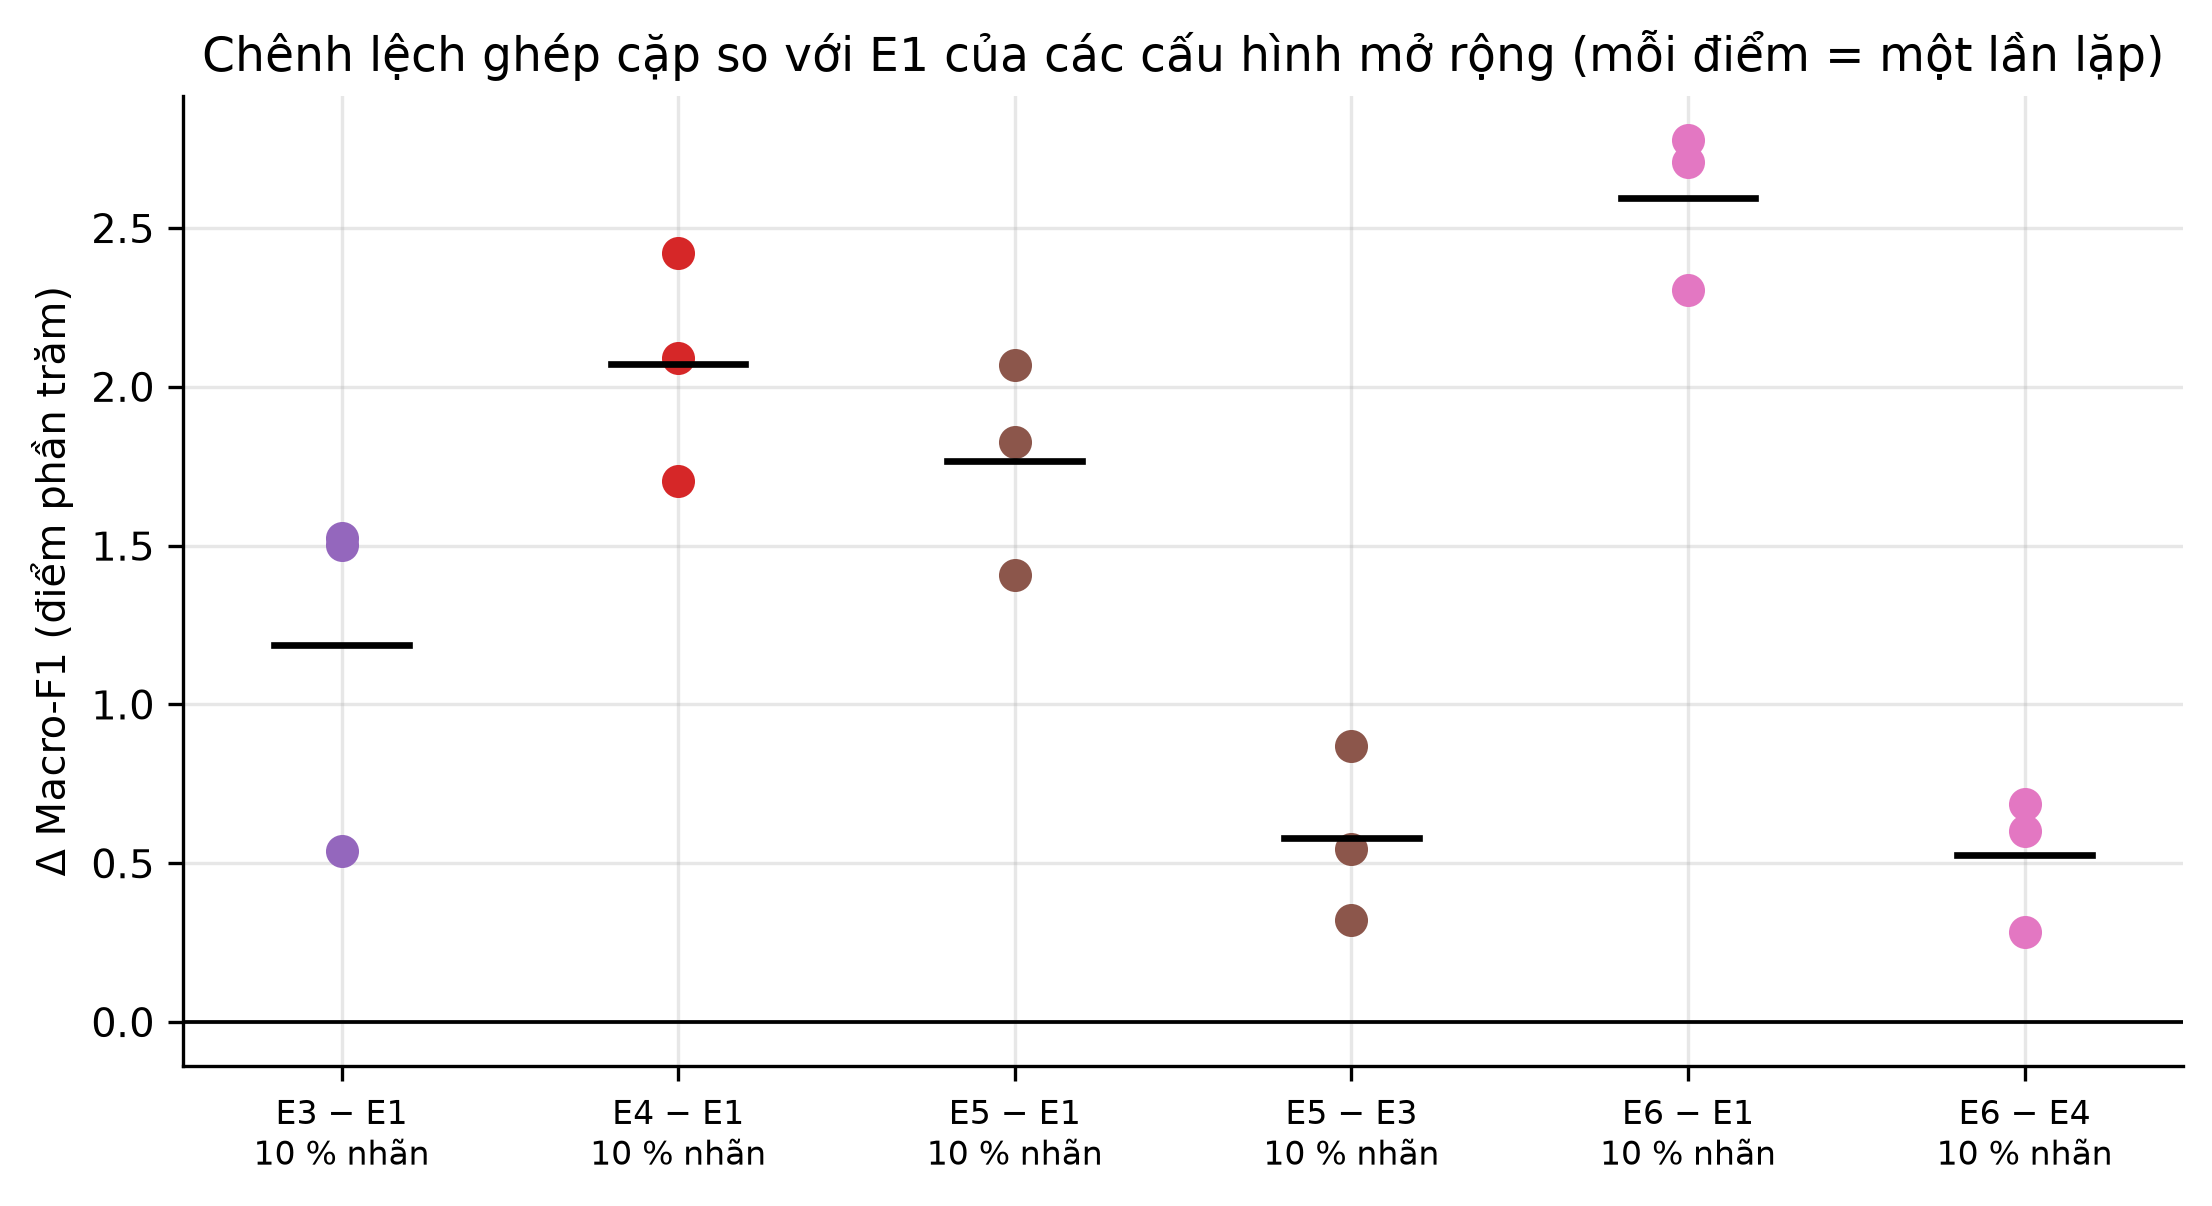

In [22]:
print("### Hình khối mở rộng (nếu đã chạy)")
for f, cap in [("fig08_lambda_sweep.png", "Khảo sát lambda_c — CHỈ trên validation"),
               ("fig06_extension_macro_f1.png", "Macro-F1 khối chính và mở rộng"),
               ("fig07_extension_delta.png", "Chênh lệch ghép cặp của khối mở rộng")]:
    print(f"\n**{cap}**")
    show_fig(f, width=820)

## 12. Kết luận và giới hạn

Phần này tự sinh từ số liệu đã nạp, không viết cứng.

In [23]:
print("=" * 74)
print("KẾT LUẬN TỰ SINH TỪ KẾT QUẢ")
print("=" * 74)

if summary:
    agg, pd_ = summary["aggregate"], summary["paired_delta"]
    print()
    print("C1 — Hiệu quả phân loại (Macro-F1 trên D_test):")
    for p in (10, 20, 50):
        d = pd_.get(f"E2_minus_E1_{p}")
        if d:
            pos = sum(1 for x in d["deltas_pp"] if x > 0)
            print(f"  @{p:>2d}% nhãn: E2 − E1 = {d['mean']:+.2f} ±{d['std']:.2f} pp"
                  f"  ({pos}/3 seed dương)")
    print()
    print("  -> Chênh lệch GIẢM ĐƠN ĐIỆU khi nhãn tăng: đây là chữ ký của label efficiency.")
    print()
    print("C2 — Vai trò của dữ liệu:")
    d = pd_.get("E2-L_minus_E1_10")
    if d:
        pos = sum(1 for x in d["deltas_pp"] if x > 0)
        print(f"  E2-L − E1 @10% = {d['mean']:+.2f} ±{d['std']:.2f} pp ({pos}/3 dương)")
        print("  -> Thêm nhánh xoay MỘT MÌNH gần như không có tác dụng.")
    # summary.json CHỈ có khoá E2−E1 và E2-L−E1; so sánh E2−E2-L phải tự tính
    # theo từng seed (ghép cặp đúng cách) từ danh sách runs.
    by = {}
    for r in summary["runs"]:
        by[(r["config"], r["label_pct"], r["seed"])] = r["test_macro_f1"]
    print("  E2 − E2-L (mở rộng nguồn ảnh cho nhánh phụ), ghép cặp theo seed:")
    for p in (10, 20, 50):
        ds = [by[("E2", p, s)] - by[("E2-L", p, s)]
              for s in REPETITION_SEEDS
              if ("E2", p, s) in by and ("E2-L", p, s) in by]
        if ds:
            m = float(np.mean(ds)); sd = float(np.std(ds, ddof=1)) if len(ds) > 1 else 0.0
            print(f"    @{p:>2d}% nhãn: {m*100:+.2f} ±{sd*100:.2f} pp"
                  f"  ({sum(1 for x in ds if x > 0)}/{len(ds)} seed dương)")
    print("  -> Lợi ích chủ yếu nằm ở việc mở rộng NGUỒN ẢNH cho nhánh phụ.")
    print()
    print("C3 — Chi phí:")
    print("  - Suy luận: E1 và E2 GIỐNG HỆT nhau (11.169.858 tham số) -> 0 đồng.")
    if not df_runs.empty:
        t = df_runs.pivot_table(index="config", columns="label_pct",
                                values="train_seconds", aggfunc="mean")
        if {"E2", "E2-L"}.issubset(set(t.index)):
            r = (t.loc["E2"] / t.loc["E2-L"]).mean()
            print(f"  - E2/E2-L ≈ {r:.3f} -> mở rộng nguồn ảnh gần như miễn phí.")

print()
print("-" * 74)
print("GIỚI HẠN (phải nêu rõ trong báo cáo)")
print("-" * 74)
for s in [
    "n = 3 lần lặp: chỉ là bằng chứng BAN ĐẦU, không kết luận ý nghĩa thống kê.",
    "Phép chia train/val/test CỐ ĐỊNH: phương sai do chính phép chia KHÔNG ước lượng được.",
    "E2 khác E2-L ở cả kho ảnh LẪN thống kê BatchNorm -> không tách sạch được hai thành phần.",
    "Bài toán 2 siêu lớp tự quy ước, khá dễ (E1 đã 93 % với 4.500 nhãn) -> thiếu headroom.",
    "Không so sánh được với bảng xếp hạng CIFAR-10 10 lớp.",
    "Độ trễ đo trên CPU/GPU máy tính KHÔNG phải bằng chứng chạy được trên vi điều khiển.",
    "Ba lần lặp thay đổi cả subset nhãn lẫn ngẫu nhiên huấn luyện; đây KHÔNG phải cross-validation.",
]:
    print(f"  - {s}")

KẾT LUẬN TỰ SINH TỪ KẾT QUẢ

C1 — Hiệu quả phân loại (Macro-F1 trên D_test):
  @10% nhãn: E2 − E1 = +1.51 ±0.06 pp  (3/3 seed dương)
  @20% nhãn: E2 − E1 = +1.34 ±0.18 pp  (3/3 seed dương)
  @50% nhãn: E2 − E1 = +0.88 ±0.07 pp  (3/3 seed dương)

  -> Chênh lệch GIẢM ĐƠN ĐIỆU khi nhãn tăng: đây là chữ ký của label efficiency.

C2 — Vai trò của dữ liệu:
  E2-L − E1 @10% = -0.06 ±0.38 pp (1/3 dương)
  -> Thêm nhánh xoay MỘT MÌNH gần như không có tác dụng.
  E2 − E2-L (mở rộng nguồn ảnh cho nhánh phụ), ghép cặp theo seed:
    @10% nhãn: +1.57 ±0.33 pp  (3/3 seed dương)
    @20% nhãn: +1.25 ±0.23 pp  (3/3 seed dương)
    @50% nhãn: +0.32 ±0.12 pp  (3/3 seed dương)
  -> Lợi ích chủ yếu nằm ở việc mở rộng NGUỒN ẢNH cho nhánh phụ.

C3 — Chi phí:
  - Suy luận: E1 và E2 GIỐNG HỆT nhau (11.169.858 tham số) -> 0 đồng.


  - E2/E2-L ≈ 0.998 -> mở rộng nguồn ảnh gần như miễn phí.

--------------------------------------------------------------------------
GIỚI HẠN (phải nêu rõ trong báo cáo)
--------------------------------------------------------------------------
  - n = 3 lần lặp: chỉ là bằng chứng BAN ĐẦU, không kết luận ý nghĩa thống kê.
  - Phép chia train/val/test CỐ ĐỊNH: phương sai do chính phép chia KHÔNG ước lượng được.
  - E2 khác E2-L ở cả kho ảnh LẪN thống kê BatchNorm -> không tách sạch được hai thành phần.
  - Bài toán 2 siêu lớp tự quy ước, khá dễ (E1 đã 93 % với 4.500 nhãn) -> thiếu headroom.
  - Không so sánh được với bảng xếp hạng CIFAR-10 10 lớp.
  - Độ trễ đo trên CPU/GPU máy tính KHÔNG phải bằng chứng chạy được trên vi điều khiển.
  - Ba lần lặp thay đổi cả subset nhãn lẫn ngẫu nhiên huấn luyện; đây KHÔNG phải cross-validation.


## 13. Tái lập trên Colab GPU

Máy local không có driver NVIDIA nên GPU không dùng được. Khối mở rộng E3–E6 được chạy trên
**Google Colab** qua `google-colab-cli`. Dưới đây là quy trình đầy đủ.

**Ước lượng thời gian** (đo thật, không phỏng đoán):

| Nền tảng | 1 epoch (E4) | 100 epoch × 12 lượt |
|---|---|---|
| CPU 16 nhân (không GPU) | 230 s (E5) | **~77 giờ** |
| Colab **L4** | ~15–19 s | **~7 giờ** |
| Colab T4 | ~20–25 s | ~9 giờ |

In [24]:
print("=" * 74)
print("HƯỚNG DẪN CHẠY KHỐI MỞ RỘNG TRÊN COLAB")
print("=" * 74)
print("""
Bước 1 — Cài CLI và auth (một lần; auth cần NGƯỜI duyệt vì là luồng copy-paste):

    pip install google-colab-cli
    export CH="$PWD/.colab-home"          # ~/.config read-only trong sandbox
    HOME="$CH" colab sessions             # in URL -> duyệt -> dán code

Bước 2 — Cấp GPU L4 và đưa code lên:

    HOME="$CH" colab new -s m8 --gpu L4
    HOME="$CH" colab upload -s m8 .colab-bundle/m8-bundle.zip /content/m8-bundle.zip
    HOME="$CH" colab upload -s m8 .colab-bundle/colab_setup.py /content/colab_setup.py
    HOME="$CH" colab exec -s m8 -f .colab-bundle/colab_setup.py

Bước 3 — Chạy 12 lượt (theo lô để tải kết quả về sớm, tránh mất tiến độ):

    cat <<'EOF' | HOME="$CH" colab exec -s m8
    import os, subprocess, sys
    os.environ['M8_CONFIGS'] = 'E3 E4'
    sys.exit(subprocess.run([sys.executable, '/content/colab_run_ext.py']).returncode)
    EOF

Bước 4 — Tải kết quả về (lặp cho từng tệp trong checkpoints_ext/):

    HOME="$CH" colab ls -s m8 /content/m8run/results/checkpoints_ext
    HOME="$CH" colab download -s m8 <remote.json> results/checkpoints_ext/<tag>.json

Bước 5 — Giải phóng GPU ngay khi xong (tránh tiêu tốn compute unit):

    HOME="$CH" colab stop -s m8
    HOME="$CH" colab sessions              # xác nhận không còn phiên nào sót

Bước 6 — Sinh lại bảng và hình từ kết quả mới:

    python scripts/make_extension_figures.py
    python scripts/make_report_data.py
""")
print("Tài liệu CLI đầy đủ: vendor/colab-cli-docs/")

HƯỚNG DẪN CHẠY KHỐI MỞ RỘNG TRÊN COLAB

Bước 1 — Cài CLI và auth (một lần; auth cần NGƯỜI duyệt vì là luồng copy-paste):

    pip install google-colab-cli
    export CH="$PWD/.colab-home"          # ~/.config read-only trong sandbox
    HOME="$CH" colab sessions             # in URL -> duyệt -> dán code

Bước 2 — Cấp GPU L4 và đưa code lên:

    HOME="$CH" colab new -s m8 --gpu L4
    HOME="$CH" colab upload -s m8 .colab-bundle/m8-bundle.zip /content/m8-bundle.zip
    HOME="$CH" colab upload -s m8 .colab-bundle/colab_setup.py /content/colab_setup.py
    HOME="$CH" colab exec -s m8 -f .colab-bundle/colab_setup.py

Bước 3 — Chạy 12 lượt (theo lô để tải kết quả về sớm, tránh mất tiến độ):

    cat <<'EOF' | HOME="$CH" colab exec -s m8
    import os, subprocess, sys
    os.environ['M8_CONFIGS'] = 'E3 E4'
    sys.exit(subprocess.run([sys.executable, '/content/colab_run_ext.py']).returncode)
    EOF

Bước 4 — Tải kết quả về (lặp cho từng tệp trong checkpoints_ext/):

    HOME="$CH" colab ls 

## 14. Phụ lục: đối chiếu tiêu chí hoàn thành của đề cương

| Tiêu chí (mục 5.3 đề cương) | Trạng thái |
|---|---|
| Xây dựng đúng quy trình đã khai báo | Ba cấu hình chính × ba mức nhãn × ba lần lặp, 100 epoch, $\lambda_{\mathrm{rot}}=0{,}5$ |
| Kiểm tra được việc tách dữ liệu và che nhãn | `results/benchmark_audit.json`: không trùng split, tập nhãn lồng nhau, $D_L\cap D_U=\varnothing$ |
| Thực hiện đối chứng bắt buộc | E1, E2-L, E2 chạy đủ ở cả ba mức nhãn |
| Báo cáo trung thực các lượt chạy | Mọi lượt đều được đưa vào báo cáo; kết quả âm được phân tích |
| Cung cấp mã nguồn tái lập | `src/m8/`, `scripts/`, README, seed, chỉ mục split |
| Mở rộng contrastive (tùy chọn) | E3–E6 — xem mục 7 để biết trạng thái thực tế |

**Nguồn số liệu.** Mọi con số trong notebook này đọc từ `results/`; không có giá trị nào được
nhập tay. Bảng và macro LaTeX trong báo cáo được sinh tự động bởi
`scripts/make_report_data.py`.